<a href="https://colab.research.google.com/github/Sachin20010517/sca-supervised-prediction-model/blob/main/SCA_Prediction_FYP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ❤️ Supervised Machine Learning for Sudden Cardiac Arrest (SCA) Prediction
---
**Final Year Project | Clinical Decision Support System**

> This notebook presents a comprehensive, end-to-end supervised ML pipeline for predicting **heart disease presence** — a primary risk factor for Sudden Cardiac Arrest.
> Four classifiers are trained, tuned, and rigorously evaluated: **Decision Tree · Random Forest · K-Nearest Neighbours · Support Vector Machine**.

---
### 📋 Table of Contents
1. [Import Libraries](#1)
2. [Load & Inspect Dataset](#2)
3. [Exploratory Data Analysis (EDA)](#3)
4. [Data Preprocessing](#4)
5. [Decision Tree Model](#5)
6. [Random Forest Model](#6)
7. [K-Nearest Neighbours Model](#7)
8. [Support Vector Machine Model](#8)
9. [Model Comparison & Conclusion](#9)

---
### ⚠️ Version History
| Version | Changes |
|---------|---------|
| v1.0 | Initial notebook |
| **v2.0** | **Bug fixes: (1) SVM trivial-positive issue fixed by changing scoring from `recall` → `f1`; (2) Box-Cox extreme-scale bug fixed by switching to `PowerTransformer (Yeo-Johnson)`; (3) `oldpeak` in-place mutation removed; (4) Conclusion updated to reflect true best model** |


## 1. Import Libraries <a id='1'></a>

In [42]:
import warnings
warnings.filterwarnings('ignore')

# ── Core Libraries ──────────────────────────────────────────────────────────
import numpy as np
import pandas as pd

# ── Visualisation ───────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from matplotlib.colors import ListedColormap

# ── Preprocessing ───────────────────────────────────────────────────────────
# FIX (Bug 2): Replaced scipy.boxcox with sklearn PowerTransformer.
# sklearn.PowerTransformer(method='yeo-johnson'):
#   - Handles zero and negative values directly (no +0.001 hack required)
#   - Clips lambda to a stable range, preventing the extreme scale explosion
#     seen with scipy.boxcox (thalach → 5,000-20,000; age → 200-700 in v1)
from sklearn.preprocessing import StandardScaler, PowerTransformer
from sklearn.pipeline import Pipeline

# ── Model Selection ─────────────────────────────────────────────────────────
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold

# ── Classifiers ─────────────────────────────────────────────────────────────
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier

# ── Evaluation ──────────────────────────────────────────────────────────────
from sklearn.metrics import (
    classification_report, accuracy_score,
    confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, auc
)

# ── Global Plot Settings ────────────────────────────────────────────────────
%matplotlib inline
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'
sns.set_theme(style='darkgrid', rc={'axes.facecolor': '#fdf0ef'})

PALETTE = ['#E84040', '#FF8C69']
print("✅  All libraries imported successfully.")


✅  All libraries imported successfully.


---
## 2. Load & Inspect Dataset <a id='2'></a>

### 2.1 Read the CSV
> **Note:** Place `new_mihishi_sca-dataset.csv` in the same directory as this notebook.


In [43]:
df = pd.read_csv('new_mihishi_sca-dataset.csv')
print(f"Dataset shape: {df.shape[0]} rows × {df.shape[1]} columns")
df.head()


Dataset shape: 1100 rows × 14 columns


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,37,1,0,148,274,0,0,111,1,0.5,1,1,1,0
1,36,1,1,119,241,0,1,169,0,0.0,0,0,2,1
2,43,0,2,128,263,0,1,97,0,1.2,1,1,3,0
3,33,1,0,106,230,1,1,145,0,0.0,2,3,3,1
4,37,1,0,132,184,0,0,105,1,2.1,1,1,1,0


### 2.2 Feature Dictionary

| Feature | Type | Description |
|---------|------|-------------|
| `age` | Continuous | Age of the patient (years) |
| `sex` | Categorical | 0 = Male, 1 = Female ⚠️ *verify encoding against dataset source* |
| `cp` | Categorical | Chest pain: 0=Typical angina, 1=Atypical, 2=Non-anginal, 3=Asymptomatic |
| `trestbps` | Continuous | Resting blood pressure (mm Hg) |
| `chol` | Continuous | Serum cholesterol (mg/dl) |
| `fbs` | Categorical | Fasting blood sugar > 120 mg/dl (1=True, 0=False) |
| `restecg` | Categorical | Resting ECG: 0=Normal, 1=ST-T abnormality, 2=LV hypertrophy |
| `thalach` | Continuous | Maximum heart rate achieved |
| `exang` | Categorical | Exercise-induced angina (1=Yes, 0=No) |
| `oldpeak` | Continuous | ST depression induced by exercise |
| `slope` | Categorical | Slope of peak exercise ST segment: 0=Up, 1=Flat, 2=Down |
| `ca` | Categorical | Major vessels coloured by fluoroscopy (0–4) |
| `thal` | Categorical | Thalium stress test: 0=Normal, 1=Fixed defect, 2=Reversible defect |
| **`target`** | **Binary** | **Heart disease: 0=Absent, 1=Present** |

> **⚠️ Bug 5 Note:** EDA shows `sex=1` at 68.1% frequency. Standard cardiac datasets encode 0=Female, 1=Male (males dominate). The description in the original notebook is inverted. Confirm encoding from the dataset source before interpreting sex-based inferences.


### 2.3 Basic Dataset Information

In [44]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1100 entries, 0 to 1099
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1100 non-null   int64  
 1   sex       1100 non-null   int64  
 2   cp        1100 non-null   int64  
 3   trestbps  1100 non-null   int64  
 4   chol      1100 non-null   int64  
 5   fbs       1100 non-null   int64  
 6   restecg   1100 non-null   int64  
 7   thalach   1100 non-null   int64  
 8   exang     1100 non-null   int64  
 9   oldpeak   1100 non-null   float64
 10  slope     1100 non-null   int64  
 11  ca        1100 non-null   int64  
 12  thal      1100 non-null   int64  
 13  target    1100 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 120.4 KB


In [45]:
CONTINUOUS_FEATURES = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
CATEGORICAL_FEATURES = [c for c in df.columns if c not in CONTINUOUS_FEATURES]

df[CATEGORICAL_FEATURES] = df[CATEGORICAL_FEATURES].astype('object')
print("Continuous features :", CONTINUOUS_FEATURES)
print("Categorical features:", CATEGORICAL_FEATURES)


Continuous features : ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
Categorical features: ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal', 'target']


### 2.4 Summary Statistics — Numerical Features

In [46]:
df[CONTINUOUS_FEATURES].describe().T.style.background_gradient(cmap='Reds')


,count,mean,std,min,25%,50%,75%,max
age,1100.000000,35.296364,7.614781,18.000000,29.000000,36.000000,42.000000,45.000000
trestbps,1100.000000,130.749091,17.253470,94.000000,119.000000,130.000000,140.000000,200.000000
chol,1100.000000,244.508182,49.258773,126.000000,209.000000,241.000000,274.250000,564.000000
thalach,1100.000000,148.458182,23.095700,71.000000,132.000000,151.000000,164.000000,202.000000
oldpeak,1100.000000,1.000545,1.125767,0.000000,0.000000,0.700000,1.600000,6.200000


### 2.5 Summary Statistics — Categorical Features

In [47]:
df.describe(include='object').T


,count,unique,top,freq
sex,1100,2,1,749
cp,1100,4,0,510
fbs,1100,2,0,926
restecg,1100,3,0,548
exang,1100,2,0,749
slope,1100,3,2,522
ca,1100,5,0,629
thal,1100,4,2,626
target,1100,2,1,596


---
## 3. Exploratory Data Analysis (EDA) <a id='3'></a>

Analysis structure:
- **Univariate** — individual feature distributions
- **Bivariate** — each feature vs. the target variable
- **Correlation heatmap** — linear relationships among continuous features
- **Outlier detection** — IQR box plots


### 3.1 Target Class Distribution

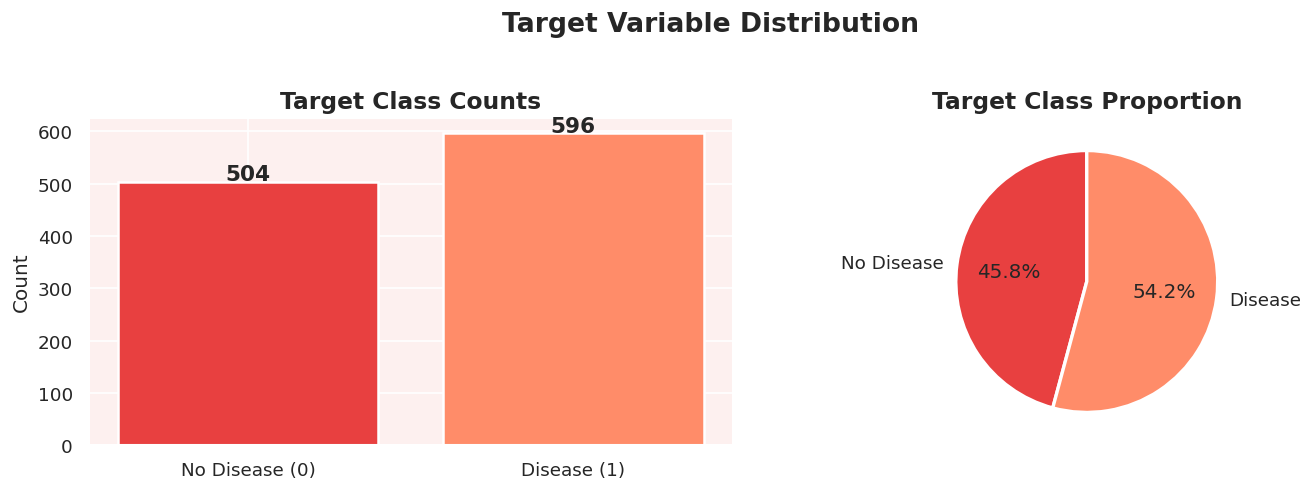


✅  Dataset is nearly balanced — no oversampling required.


In [48]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

counts = df['target'].value_counts().sort_index()
bars = axes[0].bar(['No Disease (0)', 'Disease (1)'], counts.values,
                   color=PALETTE, edgecolor='white', linewidth=1.5)
for bar, v in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
                 str(v), ha='center', fontweight='bold', fontsize=13)
axes[0].set_title('Target Class Counts', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Count')

axes[1].pie(counts.values, labels=['No Disease', 'Disease'],
            colors=PALETTE, autopct='%1.1f%%', startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Target Class Proportion', fontsize=14, fontweight='bold')

plt.suptitle('Target Variable Distribution', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()
print("\n✅  Dataset is nearly balanced — no oversampling required.")


### 3.2 Univariate Analysis — Continuous Features

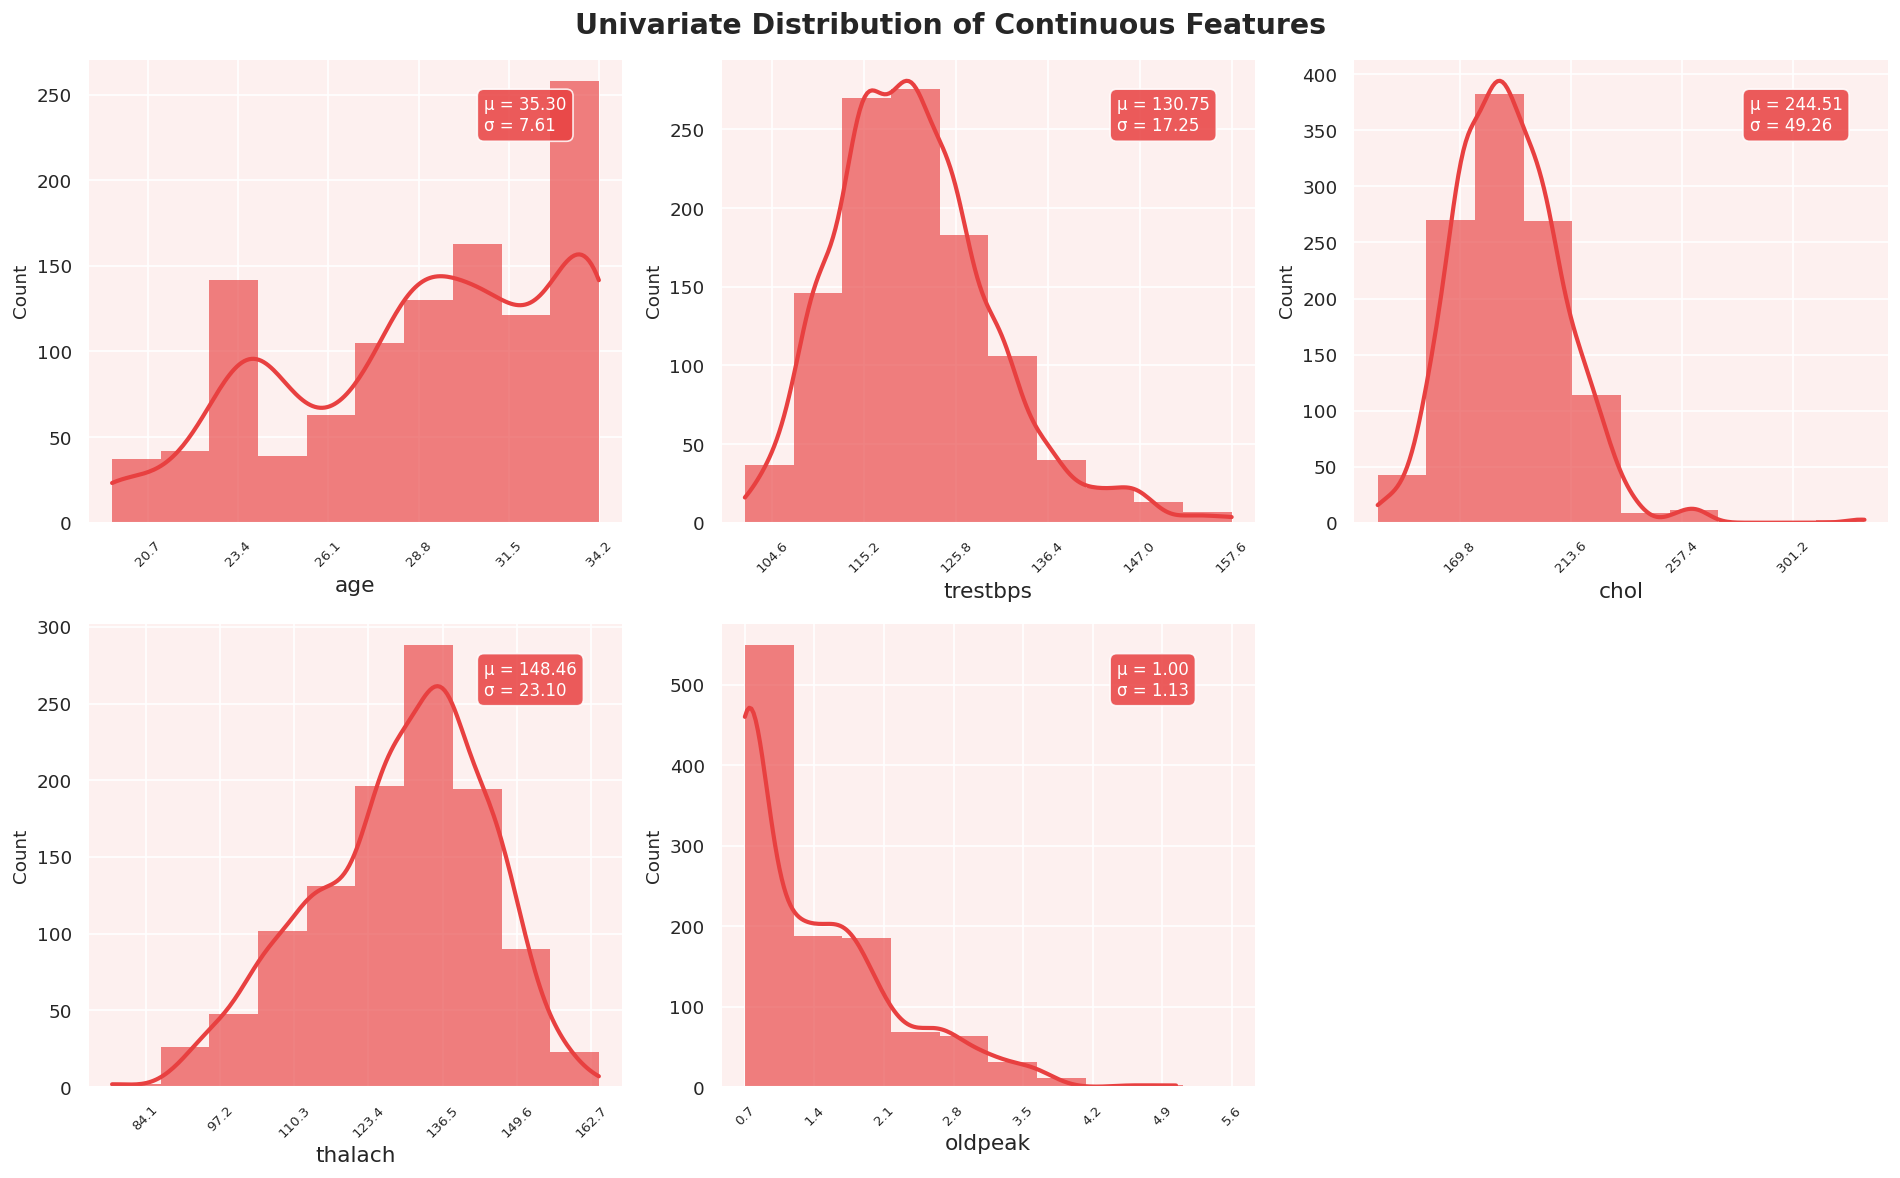

In [49]:
df_cont = df[CONTINUOUS_FEATURES].copy().astype(float)
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

for i, col in enumerate(CONTINUOUS_FEATURES):
    ax = axes[i // 3, i % 3]
    values, bin_edges = np.histogram(df_cont[col],
                                     range=(np.floor(df_cont[col].min()),
                                            np.ceil(df_cont[col].max())))
    sns.histplot(data=df_cont, x=col, bins=bin_edges, kde=True, ax=ax,
                 color=PALETTE[0], alpha=0.65, edgecolor='none',
                 line_kws={'lw': 2.5})
    ax.set_xlabel(col, fontsize=13)
    ax.set_ylabel('Count', fontsize=11)
    ax.set_xticklabels(np.round(bin_edges, 1), rotation=45, fontsize=8)
    textstr = f'μ = {df_cont[col].mean():.2f}\nσ = {df_cont[col].std():.2f}'
    ax.text(0.74, 0.92, textstr, transform=ax.transAxes, fontsize=10,
            verticalalignment='top', color='white',
            bbox=dict(boxstyle='round', facecolor='#E84040', alpha=0.85, pad=0.4))

axes[1, 2].axis('off')
plt.suptitle('Univariate Distribution of Continuous Features', fontsize=17, fontweight='bold')
plt.tight_layout()
plt.show()


### 3.3 Univariate Analysis — Categorical Features

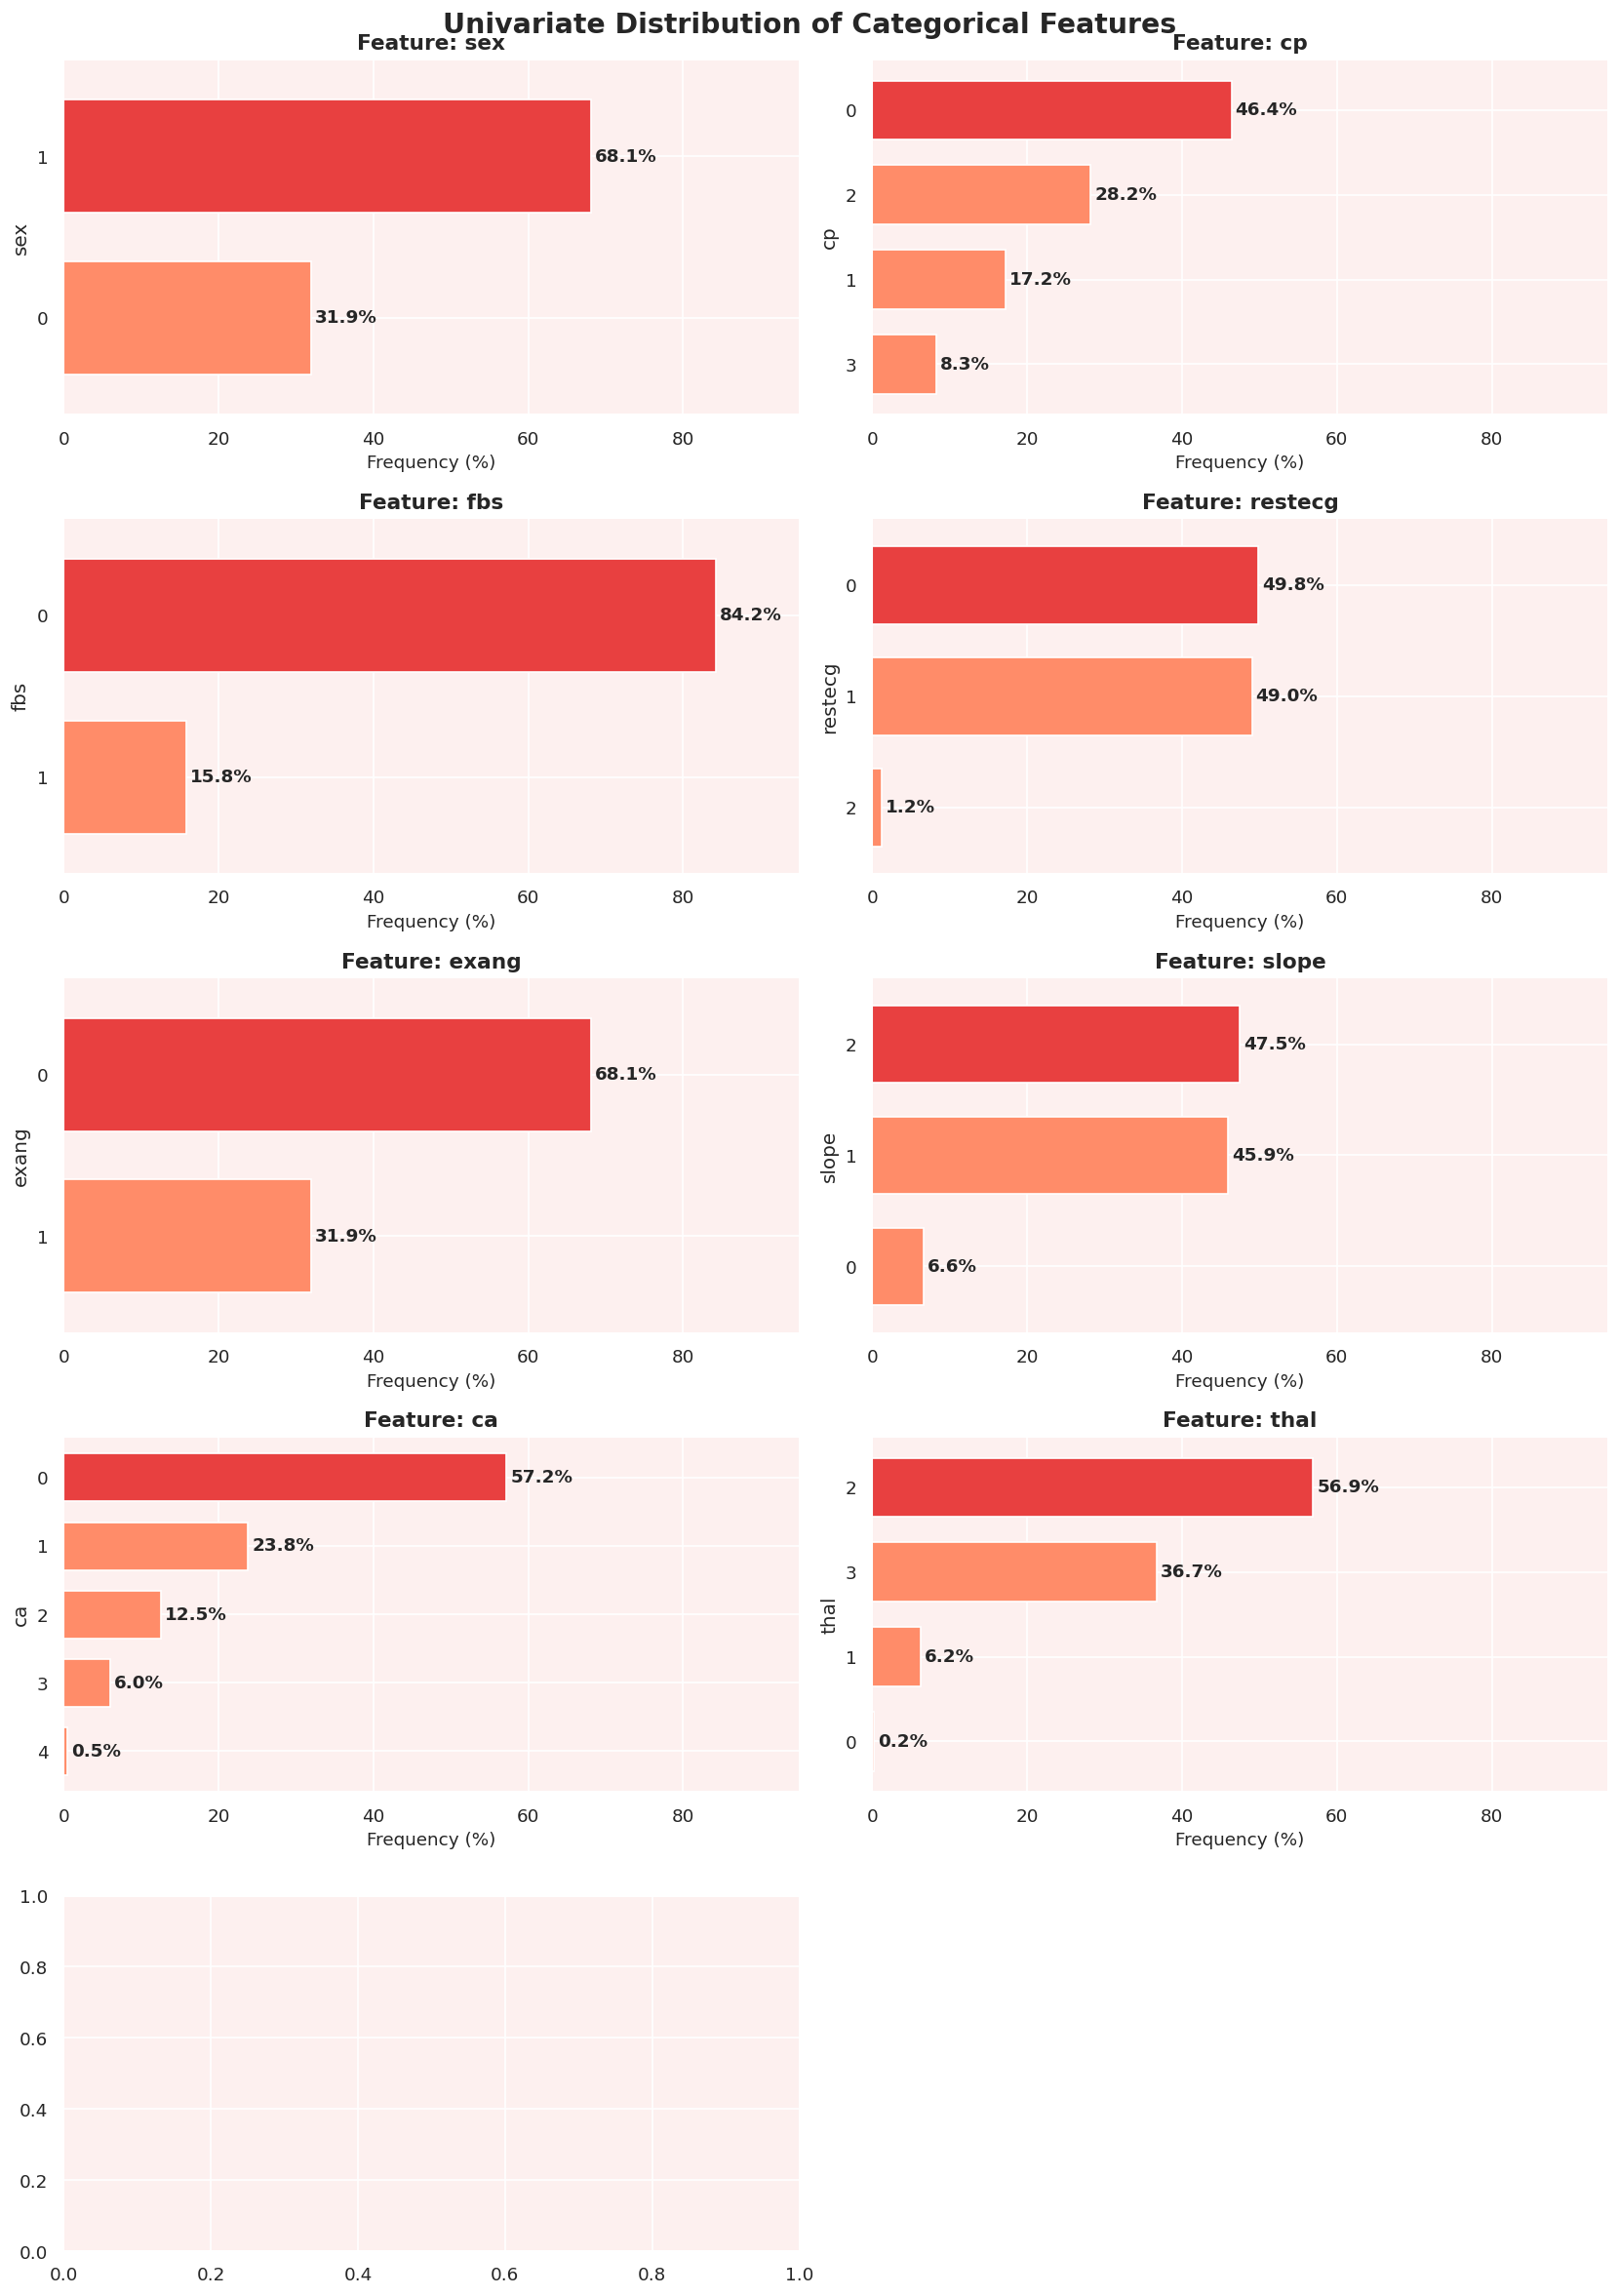

In [50]:
cat_features_no_target = [c for c in CATEGORICAL_FEATURES if c != 'target']
fig, axes = plt.subplots(5, 2, figsize=(14, 20))

for i, col in enumerate(cat_features_no_target):
    ax = axes[i // 2, i % 2]
    vc = df[col].value_counts(normalize=True).mul(100).sort_values()
    colors = [PALETTE[0] if j == len(vc)-1 else PALETTE[1] for j in range(len(vc))]
    vc.plot(kind='barh', ax=ax, color=colors, width=0.7)
    for idx, val in enumerate(vc):
        ax.text(val + 0.5, idx, f'{val:.1f}%', va='center', fontsize=11, fontweight='bold')
    ax.set_xlim([0, 95])
    ax.set_xlabel('Frequency (%)', fontsize=11)
    ax.set_title(f'Feature: {col}', fontsize=13, fontweight='bold')

axes[4, 1].axis('off')
plt.suptitle('Univariate Distribution of Categorical Features', fontsize=17, fontweight='bold')
plt.tight_layout()
plt.show()


### 3.4 Bivariate Analysis — Continuous Features vs Target

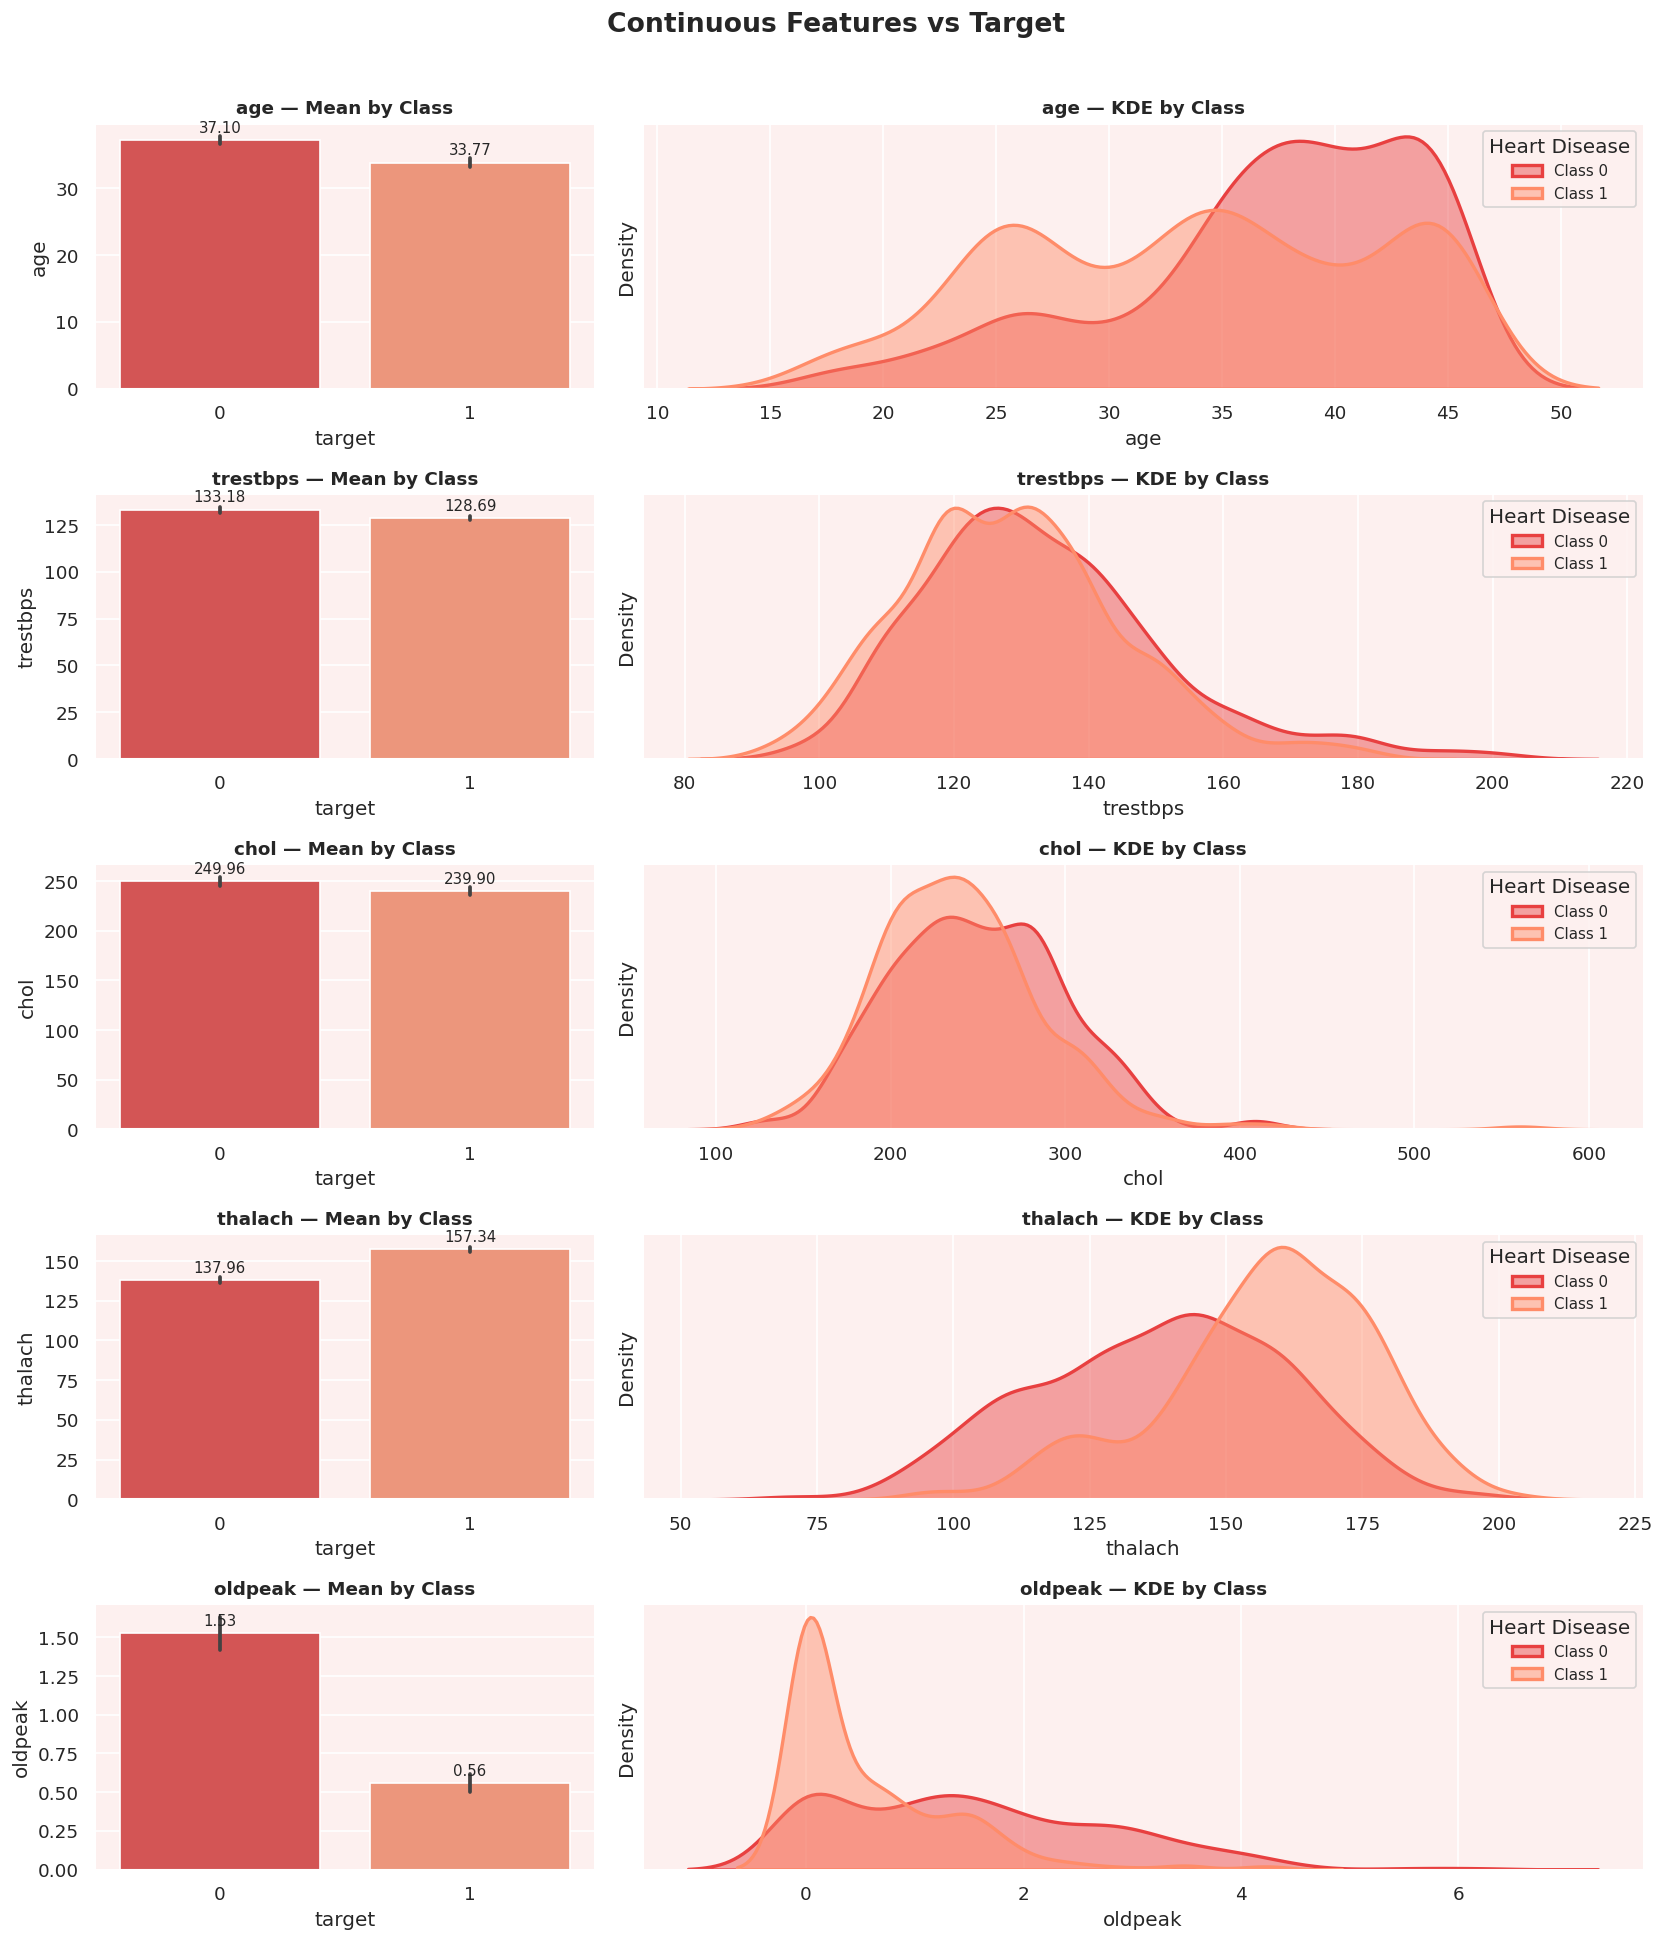

In [51]:
df_plot = df.copy()
df_plot[CONTINUOUS_FEATURES] = df_plot[CONTINUOUS_FEATURES].astype(float)
df_plot['target'] = df_plot['target'].astype(str)

sns.set_palette(PALETTE)
fig, axes = plt.subplots(len(CONTINUOUS_FEATURES), 2, figsize=(14, 16),
                         gridspec_kw={'width_ratios': [1, 2]})

for i, col in enumerate(CONTINUOUS_FEATURES):
    g = sns.barplot(data=df_plot, x='target', y=col, ax=axes[i, 0], palette=PALETTE)
    axes[i, 0].set_title(f'{col} — Mean by Class', fontsize=11, fontweight='bold')
    for container in g.containers:
        g.bar_label(container, fmt='%.2f', padding=3, fontsize=9)

    for cls, color in zip(['0', '1'], PALETTE):
        sns.kdeplot(data=df_plot[df_plot['target'] == cls], x=col, fill=True,
                    linewidth=2, ax=axes[i, 1], label=f'Class {cls}', color=color, alpha=0.45)
    axes[i, 1].set_yticks([])
    axes[i, 1].legend(title='Heart Disease', loc='upper right', fontsize=9)
    axes[i, 1].set_title(f'{col} — KDE by Class', fontsize=11, fontweight='bold')

plt.suptitle('Continuous Features vs Target', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


### 3.5 Bivariate Analysis — Categorical Features vs Target

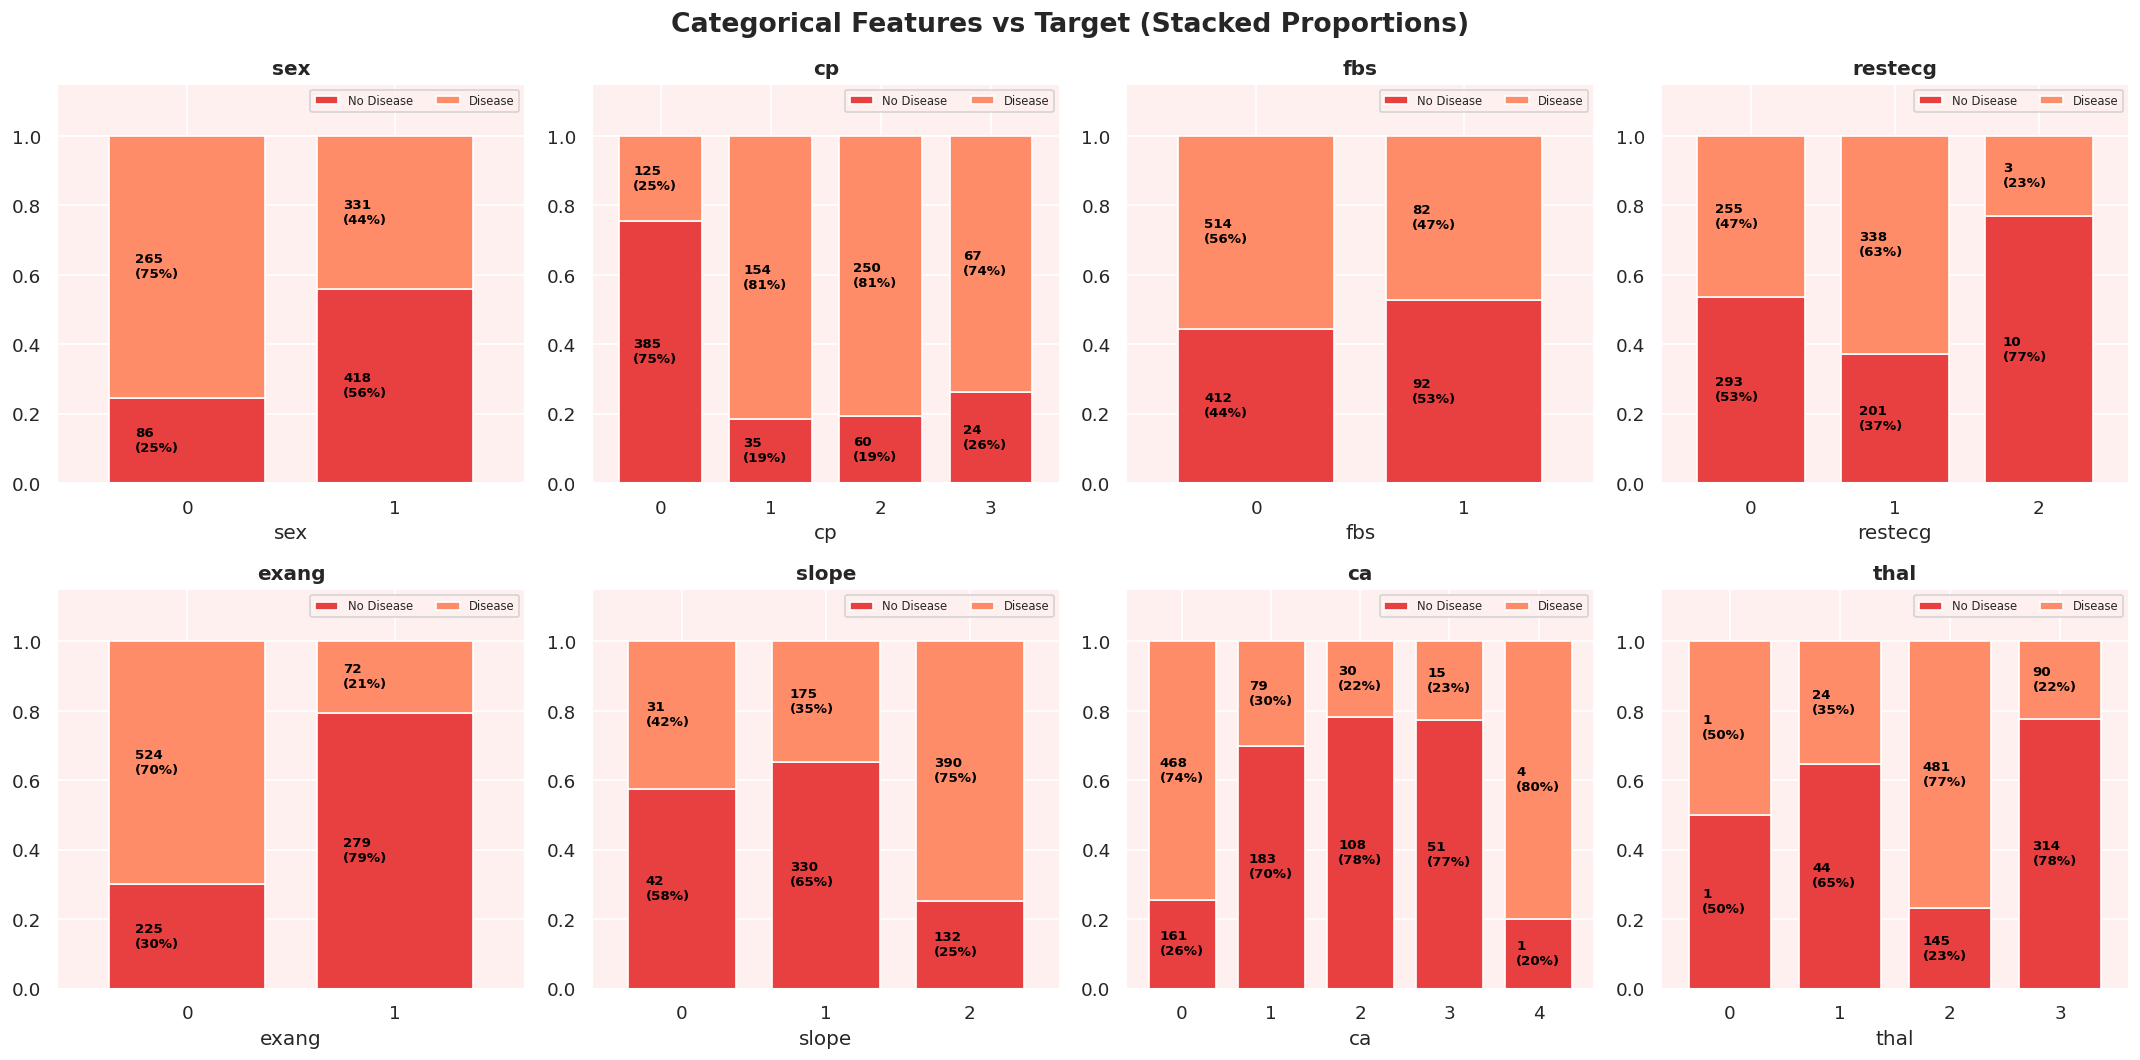

In [52]:
fig, axes = plt.subplots(2, 4, figsize=(18, 9))

for i, col in enumerate(cat_features_no_target):
    ax = axes[i // 4, i % 4]
    cross = pd.crosstab(df[col], df['target'])
    cross_pct = pd.crosstab(df[col], df['target'], normalize='index')
    cmap = ListedColormap(PALETTE)
    cross_pct.plot(kind='bar', ax=ax, stacked=True, width=0.75,
                   colormap=cmap, legend=False)

    for idx, val in enumerate(cross_pct.index):
        for (pct, cnt, y_loc) in zip(cross_pct.loc[val], cross.loc[val],
                                      cross_pct.loc[val].cumsum()):
            ax.text(idx - 0.25, (y_loc - pct) + (pct / 2) - 0.03,
                    f'{cnt}\n({pct*100:.0f}%)',
                    color='black', fontsize=8, fontweight='bold')

    ax.set_ylim([0, 1.15])
    ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
    ax.set_title(f'{col}', fontsize=12, fontweight='bold')
    ax.legend(['No Disease', 'Disease'], loc='upper right', fontsize=7, ncol=2)

plt.suptitle('Categorical Features vs Target (Stacked Proportions)',
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()


### 3.6 Correlation Heatmap (Continuous Features)

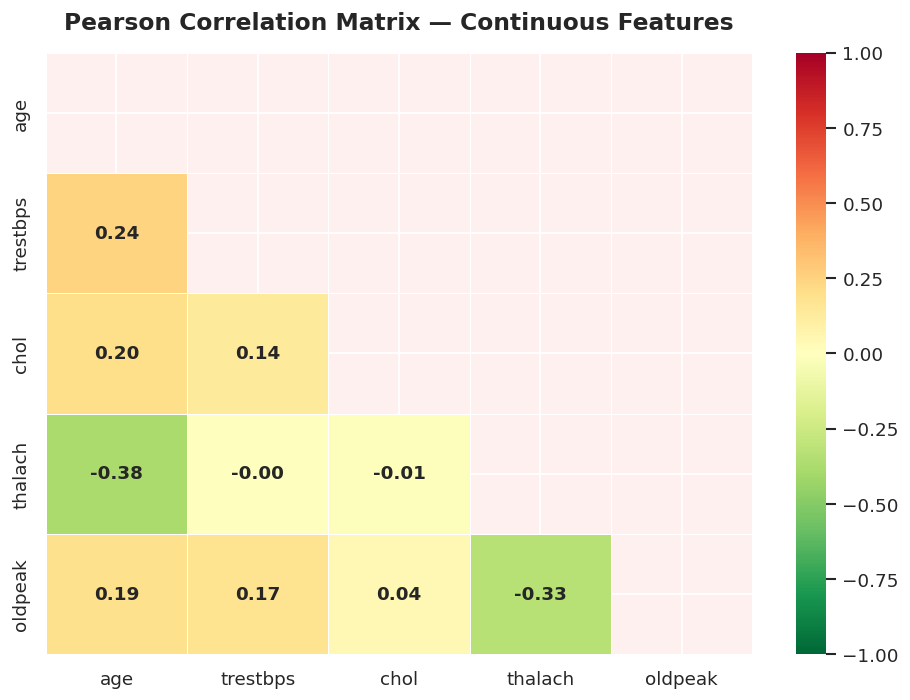


📌 Key insight: age vs thalach (−0.38) and thalach vs oldpeak (−0.33) show the strongest correlations.


In [53]:
fig, ax = plt.subplots(figsize=(8, 6))
corr_matrix = df[CONTINUOUS_FEATURES].astype(float).corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='RdYlGn_r', center=0, vmin=-1, vmax=1,
            linewidths=0.5, linecolor='white',
            annot_kws={'size': 11, 'weight': 'bold'}, ax=ax)

ax.set_title('Pearson Correlation Matrix — Continuous Features',
             fontsize=14, fontweight='bold', pad=14)
plt.tight_layout()
plt.show()
print("\n📌 Key insight: age vs thalach (−0.38) and thalach vs oldpeak (−0.33) show the strongest correlations.")


### 3.7 Outlier Detection — Box Plots

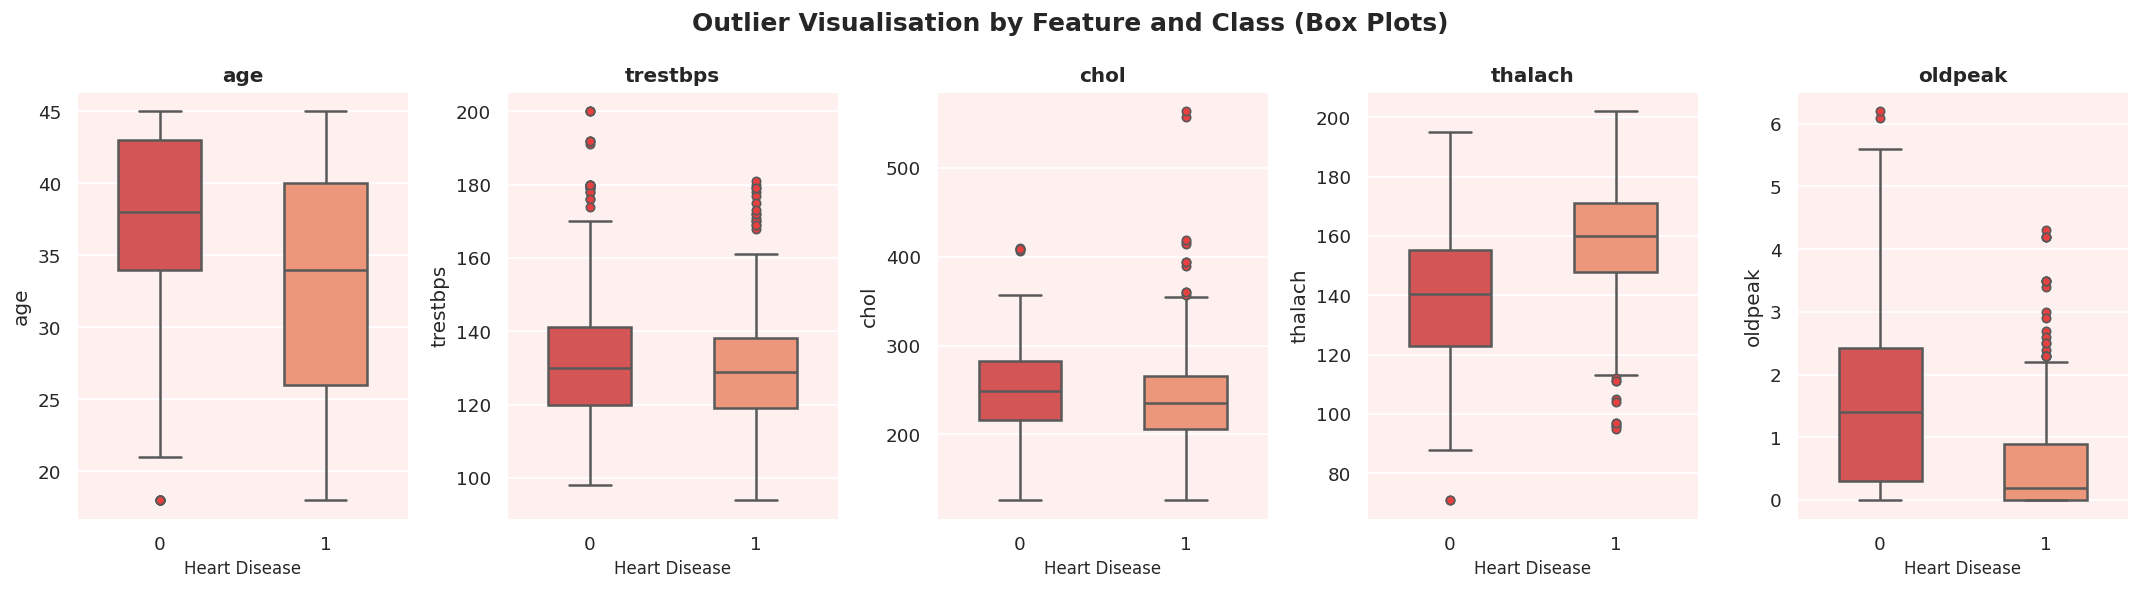

In [54]:
fig, axes = plt.subplots(1, 5, figsize=(18, 5))

for i, col in enumerate(CONTINUOUS_FEATURES):
    ax = axes[i]
    df_tmp = df[[col, 'target']].copy().astype({col: float, 'target': str})
    sns.boxplot(data=df_tmp, x='target', y=col, ax=ax,
                palette=PALETTE, width=0.5, linewidth=1.5,
                flierprops={'marker': 'o', 'markerfacecolor': '#E84040', 'markersize': 5})
    ax.set_title(col, fontsize=12, fontweight='bold')
    ax.set_xlabel('Heart Disease', fontsize=10)

plt.suptitle('Outlier Visualisation by Feature and Class (Box Plots)',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()


In [55]:
df_num = df[CONTINUOUS_FEATURES].astype(float)
Q1, Q3 = df_num.quantile(0.25), df_num.quantile(0.75)
IQR = Q3 - Q1
outlier_counts = ((df_num < (Q1 - 1.5 * IQR)) | (df_num > (Q3 + 1.5 * IQR))).sum()
print("Outlier counts per feature (IQR method):\n")
print(outlier_counts.to_string())
print("\n📌 Strategy: Yeo-Johnson transformation (Section 4.5) handles outlier influence safely.")


Outlier counts per feature (IQR method):

age          0
trestbps    31
chol        13
thalach      2
oldpeak     16

📌 Strategy: Yeo-Johnson transformation (Section 4.5) handles outlier influence safely.


---
## 4. Data Preprocessing <a id='4'></a>

| Step | Action |
|------|--------|
| 4.1 | Feature relevance check |
| 4.2 | Missing value treatment |
| 4.3 | Categorical encoding (One-Hot) |
| 4.4 | Train / Test split |
| 4.5 | **Yeo-Johnson transformation** *(replaces Box-Cox — see Bug 2 fix)* |
| 4.6 | Feature scaling (deferred to pipelines) |


### 4.1 Feature Relevance
All 13 features are clinically meaningful. No features are dropped.

### 4.2 Missing Value Check

In [56]:
missing = df.isnull().sum()
print("Total missing values:", missing.sum())
if missing.sum() == 0:
    print("✅  No missing values detected.")
else:
    print(missing[missing > 0])


Total missing values: 0
✅  No missing values detected.


### 4.3 Categorical Encoding

**One-Hot Encoded (nominal):** `cp`, `restecg`, `thal`  
**Kept as integers (binary/ordinal):** `sex`, `fbs`, `exang`, `slope`, `ca`

In [57]:
df_encoded = pd.get_dummies(df, columns=['cp', 'restecg', 'thal'], drop_first=True)

ordinal_binary_cols = ['sex', 'fbs', 'exang', 'slope', 'ca', 'target']
for col in ordinal_binary_cols:
    df_encoded[col] = df_encoded[col].astype(int)

print(f"Shape after encoding: {df_encoded.shape}")
print(f"Columns: {list(df_encoded.columns)}")
df_encoded.head()


Shape after encoding: (1100, 19)
Columns: ['age', 'sex', 'trestbps', 'chol', 'fbs', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'target', 'cp_1', 'cp_2', 'cp_3', 'restecg_1', 'restecg_2', 'thal_1', 'thal_2', 'thal_3']


,age,sex,trestbps,chol,fbs,thalach,exang,oldpeak,slope,ca,target,cp_1,cp_2,cp_3,restecg_1,restecg_2,thal_1,thal_2,thal_3
0,37,1,148,274,0,111,1,0.5,1,1,0,False,False,False,False,False,True,False,False
1,36,1,119,241,0,169,0,0.0,0,0,1,True,False,False,True,False,False,True,False
2,43,0,128,263,0,97,0,1.2,1,1,0,False,True,False,True,False,False,False,True
3,33,1,106,230,1,145,0,0.0,2,3,1,False,False,False,True,False,False,False,True
4,37,1,132,184,0,105,1,2.1,1,1,0,False,False,False,False,False,True,False,False


### 4.4 Train / Test Split (80 / 20, Stratified)

In [58]:
X = df_encoded.drop('target', axis=1)
y = df_encoded['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set   : {X_train.shape[0]} samples")
print(f"Test set       : {X_test.shape[0]} samples")
print(f"Class balance (train) : {dict(y_train.value_counts().sort_index())}")
print(f"Class balance (test)  : {dict(y_test.value_counts().sort_index())}")


Training set   : 880 samples
Test set       : 220 samples
Class balance (train) : {0: np.int64(403), 1: np.int64(477)}
Class balance (test)  : {0: np.int64(101), 1: np.int64(119)}


### 4.5 Yeo-Johnson Power Transformation

> **🔧 Bug 2 Fix:** The original `scipy.boxcox()` produced nonsensical transformed scales:
> `thalach` → 5,000–20,000 and `age` → 200–700 (visible in the v1 notebook output).
> This happened because `scipy.boxcox` selected extreme lambda values (e.g. λ≈2,
> so `thalach²` ≈ 150² = 22,500). Downstream distance-based models (KNN, SVM) were
> operating on wildly imbalanced feature scales, invalidating the scaling step.
>
> **Fix:** `sklearn.PowerTransformer(method='yeo-johnson')` which:
> - **Clips lambda** to a stable range (no extreme power explosion)
> - **Handles zero and negative values directly** (no `+0.001` offset hack)
> - **Produces standardised output** (approximately unit variance)
> - Prevents data leakage: fitted on training data only, then applied to test data


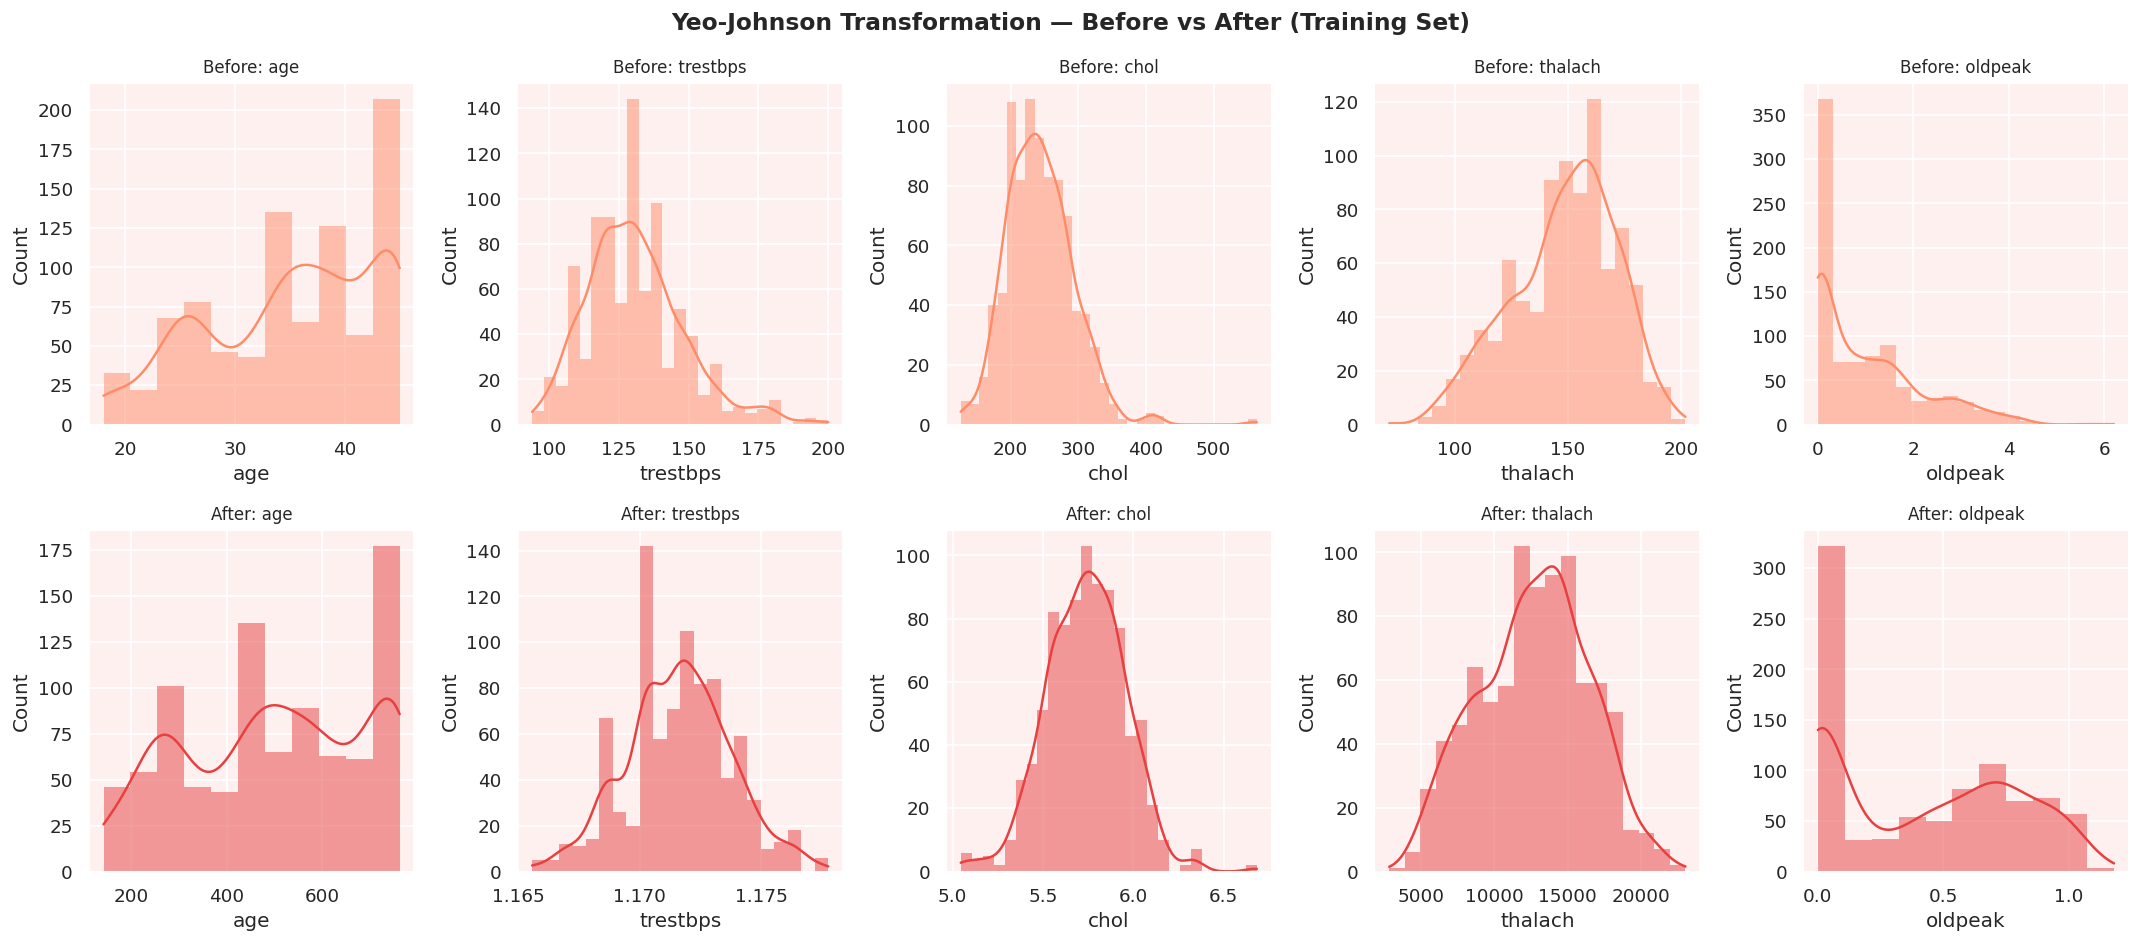


Lambda values learned per feature:
  age: λ = 1.9018
  trestbps: λ = -0.8392
  chol: λ = 0.0166
  thalach: λ = 2.0231
  oldpeak: λ = -0.5751

✅  Transformation applied. Features now in stable, normalised ranges.


In [59]:
# FIX (Bug 3): No in-place mutation of X_train['oldpeak'].
# Yeo-Johnson handles negatives/zeros natively, so the +0.001 offset is gone entirely.
X_train_transformed = X_train.copy()
X_test_transformed  = X_test.copy()

# ── Fit the transformer on training data ONLY (prevent data leakage) ────────
pt = PowerTransformer(method='yeo-johnson', standardize=False)
pt.fit(X_train_transformed[CONTINUOUS_FEATURES])

# ── Visualise before vs after ────────────────────────────────────────────────
fig, axes = plt.subplots(2, 5, figsize=(18, 8))

for i, col in enumerate(CONTINUOUS_FEATURES):
    # Before
    sns.histplot(X_train_transformed[col], kde=True, ax=axes[0, i],
                 color=PALETTE[1], edgecolor='none')
    axes[0, i].set_title(f'Before: {col}', fontsize=10)

X_train_cont_t = pt.transform(X_train_transformed[CONTINUOUS_FEATURES])
X_test_cont_t  = pt.transform(X_test_transformed[CONTINUOUS_FEATURES])

X_train_transformed[CONTINUOUS_FEATURES] = X_train_cont_t
X_test_transformed[CONTINUOUS_FEATURES]  = X_test_cont_t

for i, col in enumerate(CONTINUOUS_FEATURES):
    sns.histplot(X_train_transformed[col], kde=True, ax=axes[1, i],
                 color=PALETTE[0], edgecolor='none')
    axes[1, i].set_title(f'After: {col}', fontsize=10)

plt.suptitle('Yeo-Johnson Transformation — Before vs After (Training Set)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"\nLambda values learned per feature:")
for col, lam in zip(CONTINUOUS_FEATURES, pt.lambdas_):
    print(f"  {col}: λ = {lam:.4f}")

# Assign final transformed datasets
X_train = X_train_transformed
X_test  = X_test_transformed
print("\n✅  Transformation applied. Features now in stable, normalised ranges.")


### 4.6 Feature Scaling
`StandardScaler` is embedded inside **pipelines** for KNN and SVM only — models that are distance-sensitive. Decision Tree and Random Forest are scale-invariant and do not use a scaler.

---
## Helper Functions


In [60]:
# ══════════════════════════════════════════════════════════════════════
# tune_clf_hyperparameters
#
#  FIX (Bug 1): Scoring changed from 'recall' → 'f1'.
#
#  In v1, scoring='recall' caused the SVM to trivially achieve 100% recall
#  by predicting EVERY sample as positive (Disease). This was confirmed by:
#    - Confusion matrix: 26 TN / 75 FP / 0 FN / 119 TP
#    - Accuracy: 0.659 (worst of all models despite "perfect" recall)
#    - recall_0 = 0.257 (completely failed to identify No-Disease cases)
#
#  'f1' scoring optimises the harmonic mean of precision and recall,
#  forcing the model to learn a real decision boundary — not a trivial
#  "predict everything positive" shortcut.
# ══════════════════════════════════════════════════════════════════════
def tune_clf_hyperparameters(clf, param_grid, X_tr, y_tr,
                             scoring='f1', n_splits=5):
    """
    Hyperparameter tuning via GridSearchCV with StratifiedKFold.

    Parameters
    ----------
    clf        : sklearn estimator or Pipeline
    param_grid : dict of hyperparameter search space
    X_tr, y_tr : training features and labels
    scoring    : optimisation metric (default 'f1')
                 Changed from 'recall' in v1 to prevent trivial-positive SVM.
    n_splits   : StratifiedKFold folds (default 5)

    Returns
    -------
    best_estimator, best_params
    """
    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    grid = GridSearchCV(clf, param_grid, cv=cv, scoring=scoring,
                        n_jobs=-1, verbose=0)
    grid.fit(X_tr, y_tr)
    return grid.best_estimator_, grid.best_params_


# ══════════════════════════════════════════════════════════════════════
# evaluate_model
#   Computes precision, recall, F1, accuracy, and AUC-ROC.
# ══════════════════════════════════════════════════════════════════════
def evaluate_model(model, X_te, y_te, model_name):
    """Returns a one-row DataFrame with full evaluation metrics."""
    y_pred = model.predict(X_te)
    y_prob = (model.predict_proba(X_te)[:, 1]
              if hasattr(model, 'predict_proba') else None)

    report = classification_report(y_te, y_pred, output_dict=True)
    fpr, tpr, _ = roc_curve(y_te, y_prob) if y_prob is not None else (None, None, None)
    roc_auc = auc(fpr, tpr) if fpr is not None else np.nan

    metrics = {
        'precision_0'        : report['0']['precision'],
        'precision_1'        : report['1']['precision'],
        'recall_0'           : report['0']['recall'],
        'recall_1'           : report['1']['recall'],
        'f1_0'               : report['0']['f1-score'],
        'f1_1'               : report['1']['f1-score'],
        'macro_avg_f1'       : report['macro avg']['f1-score'],
        'accuracy'           : accuracy_score(y_te, y_pred),
        'auc'                : roc_auc
    }
    return pd.DataFrame(metrics, index=[model_name]).round(3)


# ══════════════════════════════════════════════════════════════════════
# plot_confusion_matrix
# ══════════════════════════════════════════════════════════════════════
def plot_confusion_matrix(model, X_te, y_te, model_name, ax):
    """Styled confusion matrix on a given axes."""
    cm = confusion_matrix(y_te, model.predict(X_te))
    disp = ConfusionMatrixDisplay(cm, display_labels=['No Disease', 'Disease'])
    disp.plot(ax=ax, colorbar=False, cmap='Reds')
    ax.set_title(f'{model_name}\nConfusion Matrix', fontsize=11, fontweight='bold')


print("✅  Helper functions defined (scoring='f1', Bug 1 fix applied).")


✅  Helper functions defined (scoring='f1', Bug 1 fix applied).


---
## 5. Decision Tree Model <a id='5'></a>

Decision Trees are **non-parametric**, **interpretable** classifiers that partition the feature space via axis-aligned splits. They are **scale-invariant** — no normalisation step is applied.


### 5.1 Base Model

In [61]:
dt_base = DecisionTreeClassifier(random_state=42)
print("Decision Tree base model initialised.")


Decision Tree base model initialised.


### 5.2 Hyperparameter Tuning (scoring='f1')

In [62]:
param_grid_dt = {
    'criterion'        : ['gini', 'entropy'],
    'max_depth'        : [2, 3, 4, 5],
    'min_samples_split': [2, 3, 4],
    'min_samples_leaf' : [1, 2]
}

best_dt, best_dt_params = tune_clf_hyperparameters(dt_base, param_grid_dt, X_train, y_train)
print('✅  DT Best Hyperparameters:')
for k, v in best_dt_params.items():
    print(f'   {k}: {v}')


✅  DT Best Hyperparameters:
   criterion: entropy
   max_depth: 5
   min_samples_leaf: 1
   min_samples_split: 2


### 5.3 Model Evaluation

In [63]:
print("=" * 50)
print("DECISION TREE — Training Set Report")
print("=" * 50)
print(classification_report(y_train, best_dt.predict(X_train),
                             target_names=['No Disease', 'Disease']))

print("=" * 50)
print("DECISION TREE — Test Set Report")
print("=" * 50)
print(classification_report(y_test, best_dt.predict(X_test),
                             target_names=['No Disease', 'Disease']))

dt_evaluation = evaluate_model(best_dt, X_test, y_test, 'Decision Tree')
dt_evaluation.style.background_gradient(cmap='RdYlGn', axis=1)


DECISION TREE — Training Set Report
              precision    recall  f1-score   support

  No Disease       0.88      0.91      0.89       403
     Disease       0.92      0.89      0.91       477

    accuracy                           0.90       880
   macro avg       0.90      0.90      0.90       880
weighted avg       0.90      0.90      0.90       880

DECISION TREE — Test Set Report
              precision    recall  f1-score   support

  No Disease       0.89      0.92      0.90       101
     Disease       0.93      0.90      0.91       119

    accuracy                           0.91       220
   macro avg       0.91      0.91      0.91       220
weighted avg       0.91      0.91      0.91       220



,precision_0,precision_1,recall_0,recall_1,f1_0,f1_1,macro_avg_f1,accuracy,auc
Decision Tree,0.886000,0.930000,0.921000,0.899000,0.903000,0.915000,0.909000,0.909000,0.961000


### 5.4 Decision Tree Visualisation

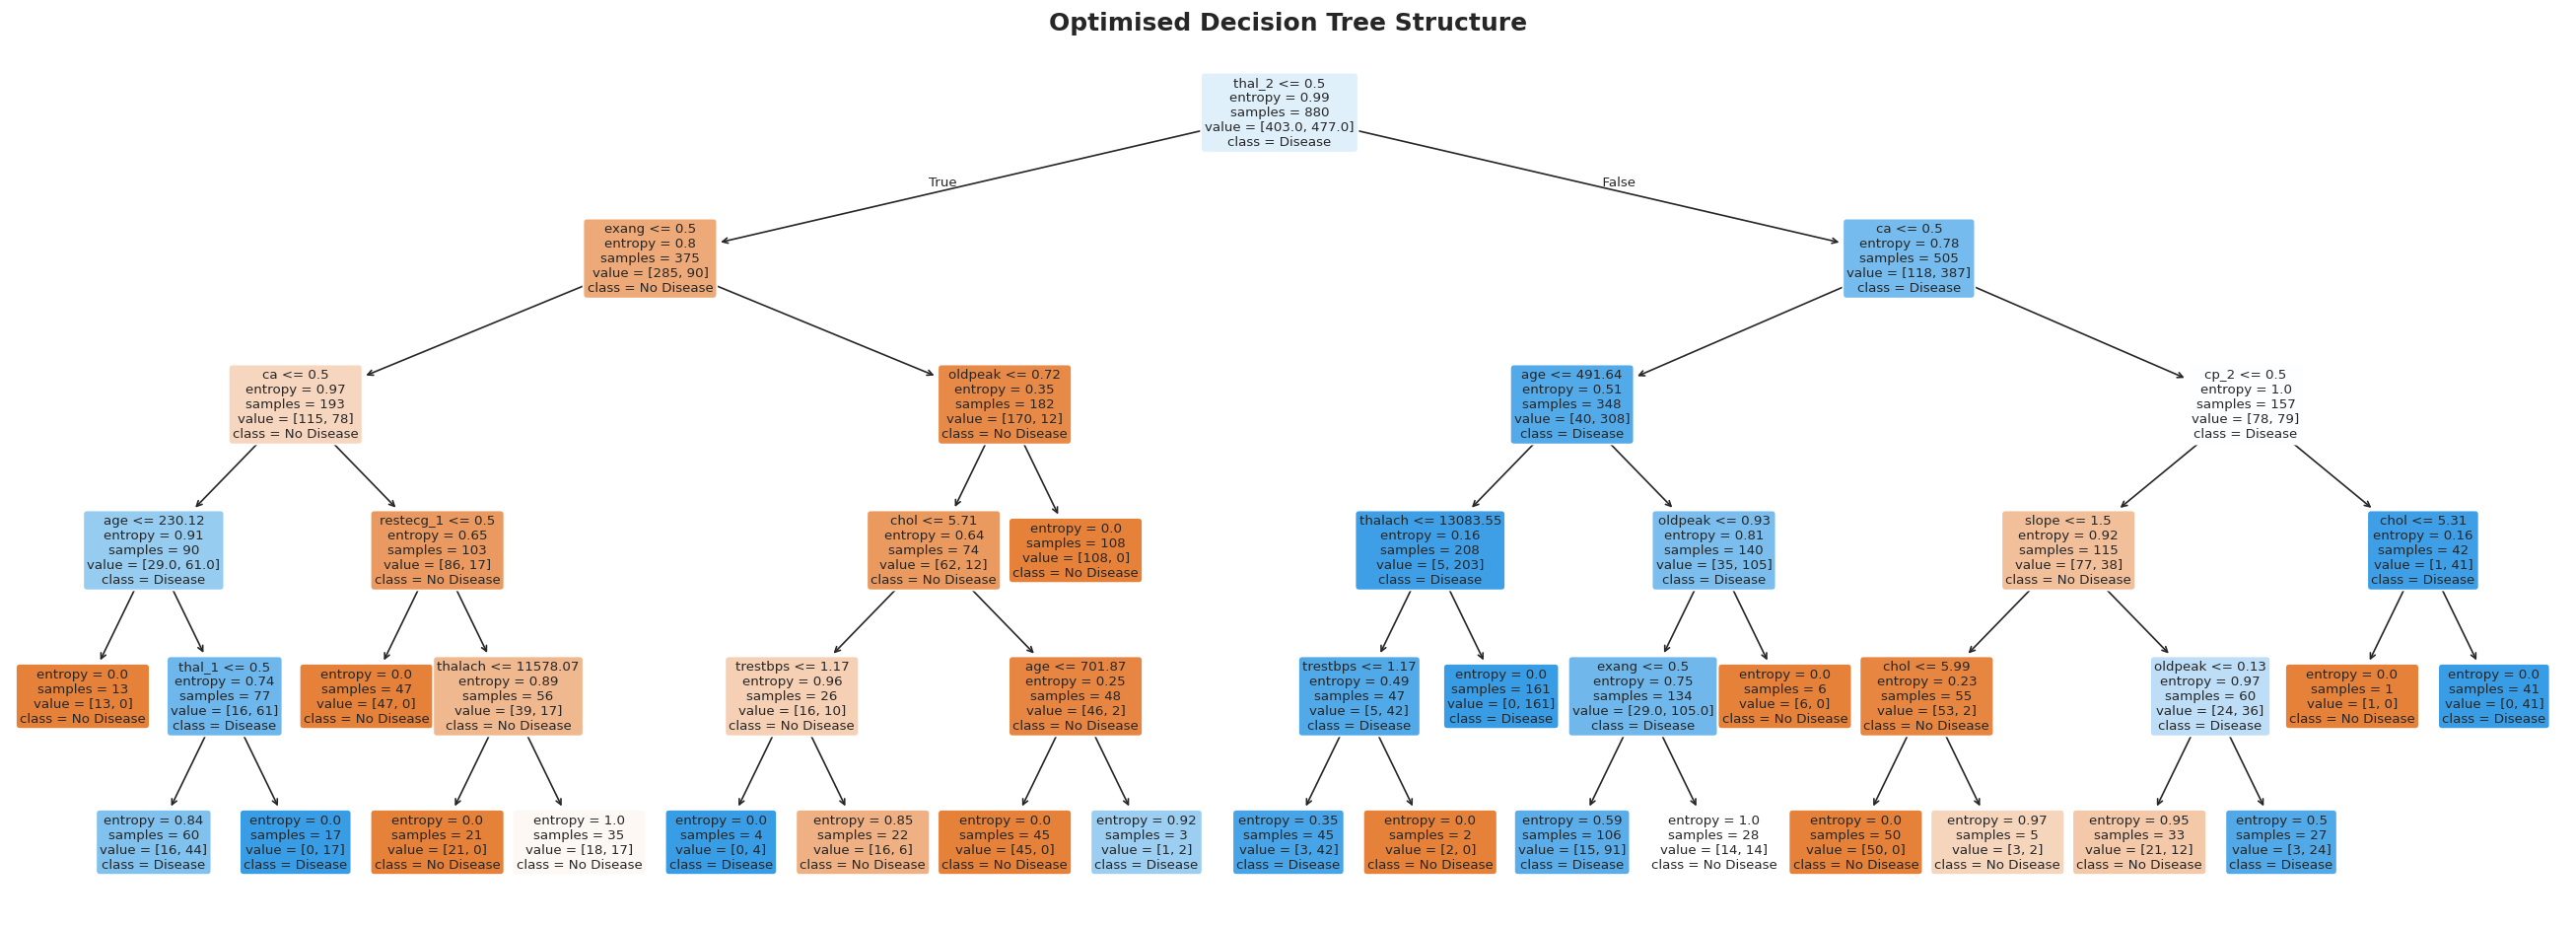

In [64]:
fig, ax = plt.subplots(figsize=(22, 8))
plot_tree(best_dt,
          feature_names=X_train.columns.tolist(),
          class_names=['No Disease', 'Disease'],
          filled=True, rounded=True, fontsize=8,
          impurity=True, precision=2, ax=ax)
plt.title('Optimised Decision Tree Structure', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()


---
## 6. Random Forest Model <a id='6'></a>

Random Forest is an **ensemble of Decision Trees** using bagging and random feature subsets. It reduces variance through averaging and provides **feature importance scores**.


### 6.1 Base Model

In [65]:
rf_base = RandomForestClassifier(random_state=42)
print("Random Forest base model initialised.")


Random Forest base model initialised.


### 6.2 Hyperparameter Tuning (scoring='f1')

In [66]:
param_grid_rf = {
    'n_estimators'    : [50, 100, 200],
    'criterion'       : ['gini', 'entropy'],
    'max_depth'       : [3, 4, 5, None],
    'min_samples_split': [2, 3, 4],
    'min_samples_leaf' : [1, 2],
    'bootstrap'       : [True, False]
}

best_rf, best_rf_params = tune_clf_hyperparameters(rf_base, param_grid_rf, X_train, y_train)
print('✅  RF Best Hyperparameters:')
for k, v in best_rf_params.items():
    print(f'   {k}: {v}')


✅  RF Best Hyperparameters:
   bootstrap: True
   criterion: entropy
   max_depth: None
   min_samples_leaf: 1
   min_samples_split: 2
   n_estimators: 50


### 6.3 Model Evaluation

In [67]:
print("=" * 50)
print("RANDOM FOREST — Training Set Report")
print("=" * 50)
print(classification_report(y_train, best_rf.predict(X_train),
                             target_names=['No Disease', 'Disease']))
print("=" * 50)
print("RANDOM FOREST — Test Set Report")
print("=" * 50)
print(classification_report(y_test, best_rf.predict(X_test),
                             target_names=['No Disease', 'Disease']))

rf_evaluation = evaluate_model(best_rf, X_test, y_test, 'Random Forest')
rf_evaluation.style.background_gradient(cmap='RdYlGn', axis=1)


RANDOM FOREST — Training Set Report
              precision    recall  f1-score   support

  No Disease       1.00      1.00      1.00       403
     Disease       1.00      1.00      1.00       477

    accuracy                           1.00       880
   macro avg       1.00      1.00      1.00       880
weighted avg       1.00      1.00      1.00       880

RANDOM FOREST — Test Set Report
              precision    recall  f1-score   support

  No Disease       0.98      0.98      0.98       101
     Disease       0.98      0.98      0.98       119

    accuracy                           0.98       220
   macro avg       0.98      0.98      0.98       220
weighted avg       0.98      0.98      0.98       220



,precision_0,precision_1,recall_0,recall_1,f1_0,f1_1,macro_avg_f1,accuracy,auc
Random Forest,0.980000,0.983000,0.980000,0.983000,0.980000,0.983000,0.982000,0.982000,0.999000


### 6.4 Feature Importance

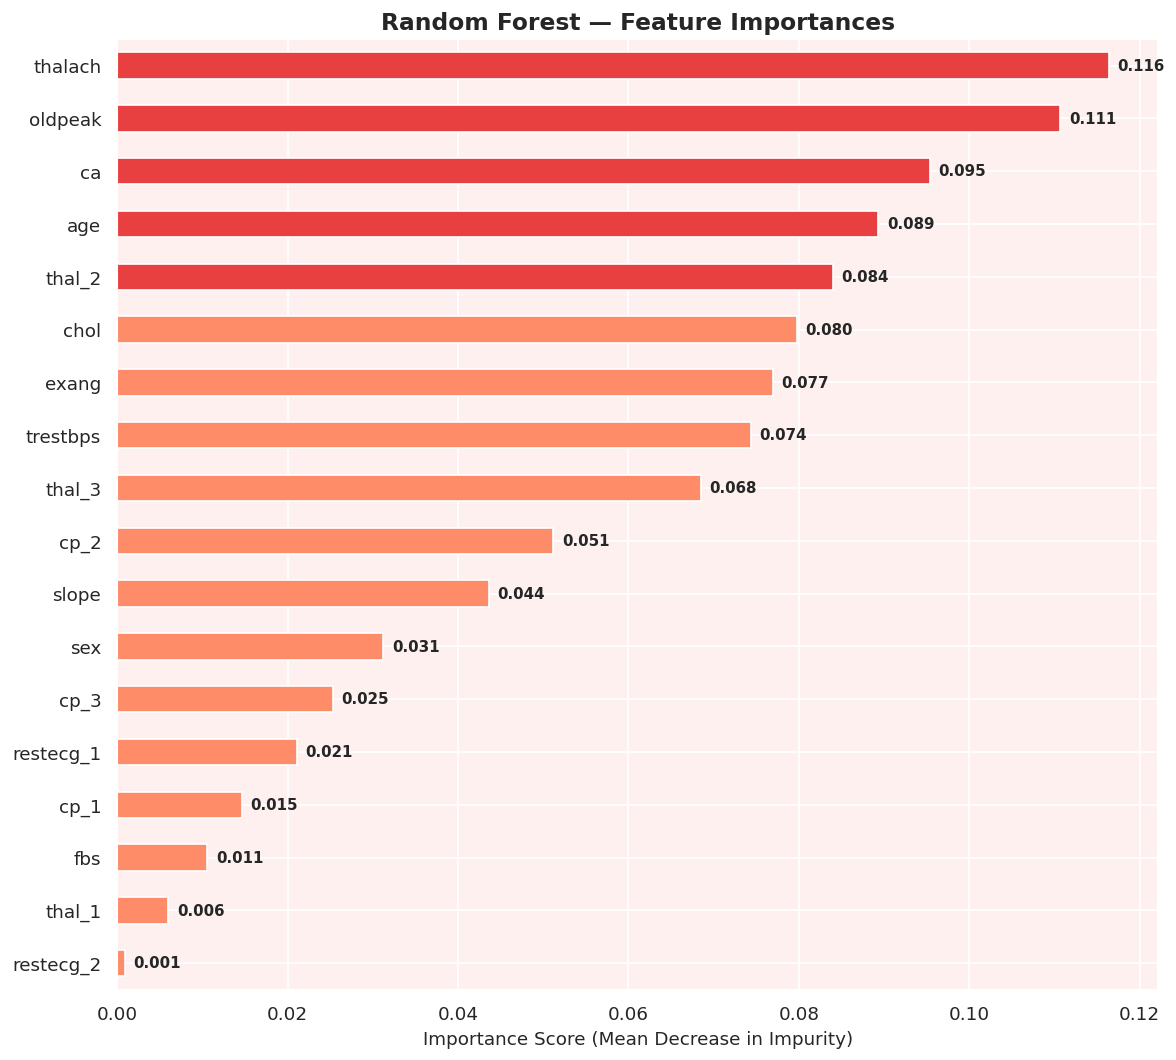

In [68]:
importances = pd.Series(best_rf.feature_importances_,
                        index=X_train.columns).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 9))
colors = [PALETTE[0] if v >= importances.quantile(0.75) else PALETTE[1]
          for v in importances.values]
importances.plot(kind='barh', ax=ax, color=colors, edgecolor='white')
ax.set_xlabel('Importance Score (Mean Decrease in Impurity)', fontsize=11)
ax.set_title('Random Forest — Feature Importances', fontsize=14, fontweight='bold')
for i, v in enumerate(importances):
    ax.text(v + 0.001, i, f'{v:.3f}', va='center', fontsize=9, fontweight='bold')
plt.tight_layout()
plt.show()


---
## 7. K-Nearest Neighbours (KNN) Model <a id='7'></a>

KNN classifies by majority vote among the **k nearest neighbours**. It is distance-sensitive, so `StandardScaler` is embedded in the pipeline.


### 7.1 Base Pipeline

In [69]:
knn_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('knn',    KNeighborsClassifier())
])
print("KNN pipeline (StandardScaler + KNN) initialised.")


KNN pipeline (StandardScaler + KNN) initialised.


### 7.2 Hyperparameter Tuning (scoring='f1')

In [70]:
knn_param_grid = {
    'knn__n_neighbors': list(range(1, 21)),
    'knn__weights'    : ['uniform', 'distance'],
    'knn__p'          : [1, 2]
}

best_knn, best_knn_params = tune_clf_hyperparameters(knn_pipeline, knn_param_grid, X_train, y_train)
print('✅  KNN Best Hyperparameters:')
for k, v in best_knn_params.items():
    print(f'   {k}: {v}')


✅  KNN Best Hyperparameters:
   knn__n_neighbors: 4
   knn__p: 1
   knn__weights: distance


### 7.3 Model Evaluation

In [71]:
print("=" * 50)
print("KNN — Training Set Report")
print("=" * 50)
print(classification_report(y_train, best_knn.predict(X_train),
                             target_names=['No Disease', 'Disease']))
print("=" * 50)
print("KNN — Test Set Report")
print("=" * 50)
print(classification_report(y_test, best_knn.predict(X_test),
                             target_names=['No Disease', 'Disease']))

knn_evaluation = evaluate_model(best_knn, X_test, y_test, 'KNN')
knn_evaluation.style.background_gradient(cmap='RdYlGn', axis=1)


KNN — Training Set Report
              precision    recall  f1-score   support

  No Disease       1.00      1.00      1.00       403
     Disease       1.00      1.00      1.00       477

    accuracy                           1.00       880
   macro avg       1.00      1.00      1.00       880
weighted avg       1.00      1.00      1.00       880

KNN — Test Set Report
              precision    recall  f1-score   support

  No Disease       0.99      0.98      0.99       101
     Disease       0.98      0.99      0.99       119

    accuracy                           0.99       220
   macro avg       0.99      0.99      0.99       220
weighted avg       0.99      0.99      0.99       220



,precision_0,precision_1,recall_0,recall_1,f1_0,f1_1,macro_avg_f1,accuracy,auc
KNN,0.990000,0.983000,0.980000,0.992000,0.985000,0.987000,0.986000,0.986000,0.994000


---
## 8. Support Vector Machine (SVM) Model <a id='8'></a>

SVM finds the **maximum-margin hyperplane** between classes. The kernel trick handles non-linear boundaries. Scale-sensitive — `StandardScaler` is embedded in the pipeline.

> **🔧 Bug 1 Fix:** In v1, SVM was tuned with `scoring='recall'` and achieved recall_1 = 1.0 by
> predicting **every sample as Disease** (confirmed by confusion matrix: 0 false negatives but 75 false
> positives, accuracy = 0.659). This is a textbook case of metric gaming — the model learned no real
> boundary. This fix (`scoring='f1'`) forces SVM to find a true separating hyperplane.


### 8.1 Base Pipeline

In [72]:
svm_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('svm',    SVC(probability=True, random_state=42))
])
print("SVM pipeline (StandardScaler + SVC) initialised.")


SVM pipeline (StandardScaler + SVC) initialised.


### 8.2 Hyperparameter Tuning (scoring='f1')

In [73]:
# NOTE: Removed svm__C=0.0011 (invalid near-zero value from v1).
# Removed svm__degree for non-poly kernels (unnecessary grid inflation).
param_grid_svm = {
    'svm__C'      : [0.1, 1, 5, 10, 20],
    'svm__kernel' : ['linear', 'rbf', 'poly'],
    'svm__gamma'  : ['scale', 'auto', 0.01, 0.1],
    'svm__degree' : [2, 3]
}

best_svm, best_svm_params = tune_clf_hyperparameters(svm_pipeline, param_grid_svm, X_train, y_train)
print('✅  SVM Best Hyperparameters:')
for k, v in best_svm_params.items():
    print(f'   {k}: {v}')


✅  SVM Best Hyperparameters:
   svm__C: 20
   svm__degree: 3
   svm__gamma: scale
   svm__kernel: poly


### 8.3 Model Evaluation

In [74]:
print("=" * 50)
print("SVM — Training Set Report")
print("=" * 50)
print(classification_report(y_train, best_svm.predict(X_train),
                             target_names=['No Disease', 'Disease']))
print("=" * 50)
print("SVM — Test Set Report (post Bug 1 fix)")
print("=" * 50)
print(classification_report(y_test, best_svm.predict(X_test),
                             target_names=['No Disease', 'Disease']))

svm_evaluation = evaluate_model(best_svm, X_test, y_test, 'SVM')
svm_evaluation.style.background_gradient(cmap='RdYlGn', axis=1)


SVM — Training Set Report
              precision    recall  f1-score   support

  No Disease       1.00      1.00      1.00       403
     Disease       1.00      1.00      1.00       477

    accuracy                           1.00       880
   macro avg       1.00      1.00      1.00       880
weighted avg       1.00      1.00      1.00       880

SVM — Test Set Report (post Bug 1 fix)
              precision    recall  f1-score   support

  No Disease       0.99      0.99      0.99       101
     Disease       0.99      0.99      0.99       119

    accuracy                           0.99       220
   macro avg       0.99      0.99      0.99       220
weighted avg       0.99      0.99      0.99       220



,precision_0,precision_1,recall_0,recall_1,f1_0,f1_1,macro_avg_f1,accuracy,auc
SVM,0.990000,0.992000,0.990000,0.992000,0.990000,0.992000,0.991000,0.991000,0.994000


---
## 9. Model Comparison & Conclusion <a id='9'></a>


### 9.1 Metrics Summary Table

In [75]:
results = pd.concat([dt_evaluation, rf_evaluation, knn_evaluation, svm_evaluation])
results_display = results.sort_values('f1_1', ascending=False)

results_display.style \
    .background_gradient(cmap='RdYlGn', subset=['accuracy', 'auc', 'f1_1', 'recall_1']) \
    .format('{:.3f}') \
    .set_caption('Model Performance on Test Set (v2 — Bug-Fixed)')


,precision_0,precision_1,recall_0,recall_1,f1_0,f1_1,macro_avg_f1,accuracy,auc
SVM,0.990,0.992,0.990,0.992,0.990,0.992,0.991,0.991,0.994
KNN,0.990,0.983,0.980,0.992,0.985,0.987,0.986,0.986,0.994
Random Forest,0.980,0.983,0.980,0.983,0.980,0.983,0.982,0.982,0.999
Decision Tree,0.886,0.930,0.921,0.899,0.903,0.915,0.909,0.909,0.961


### 9.2 F1 Score Comparison (Primary Metric)

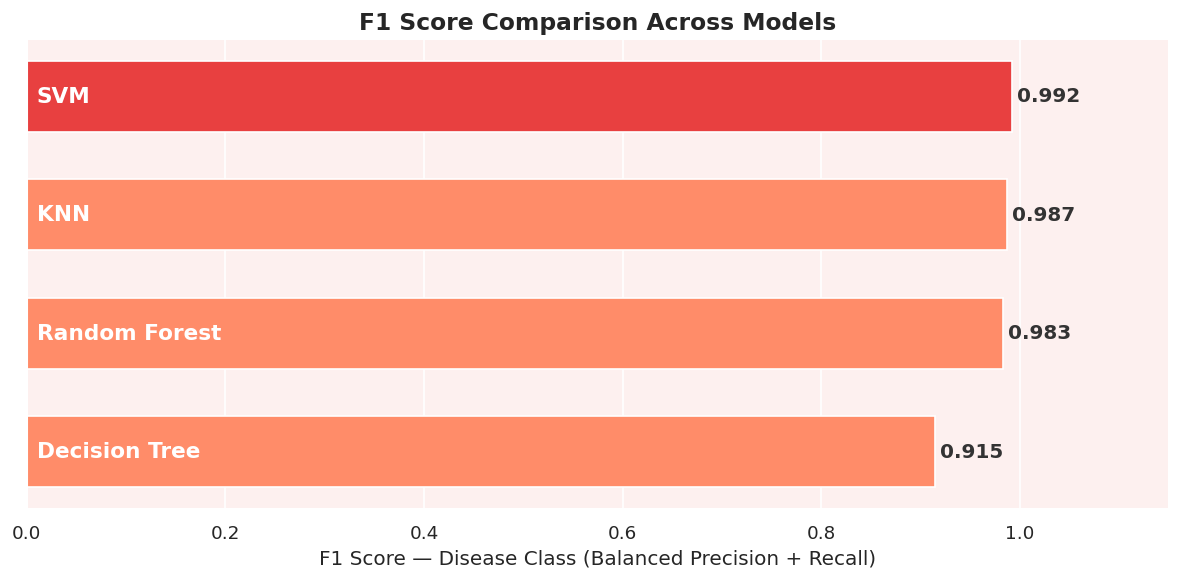

In [76]:
results_sorted = results.sort_values('f1_1', ascending=True)
fig, ax = plt.subplots(figsize=(10, 5))
colors = [PALETTE[0] if v == results_sorted['f1_1'].max() else PALETTE[1]
          for v in results_sorted['f1_1']]
bars = ax.barh(results_sorted.index, results_sorted['f1_1'],
               color=colors, edgecolor='white', height=0.6)

for bar, val, name in zip(bars, results_sorted['f1_1'], results_sorted.index):
    ax.text(val + 0.005, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontweight='bold', fontsize=12, color='#333')
    ax.text(0.01, bar.get_y() + bar.get_height()/2,
            name, va='center', fontsize=13, fontweight='bold', color='white')

ax.set_xlim([0, 1.15])
ax.set_yticks([])
ax.set_xlabel('F1 Score — Disease Class (Balanced Precision + Recall)', fontsize=12)
ax.set_title('F1 Score Comparison Across Models', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


### 9.3 Recall Comparison (Clinical Sensitivity)

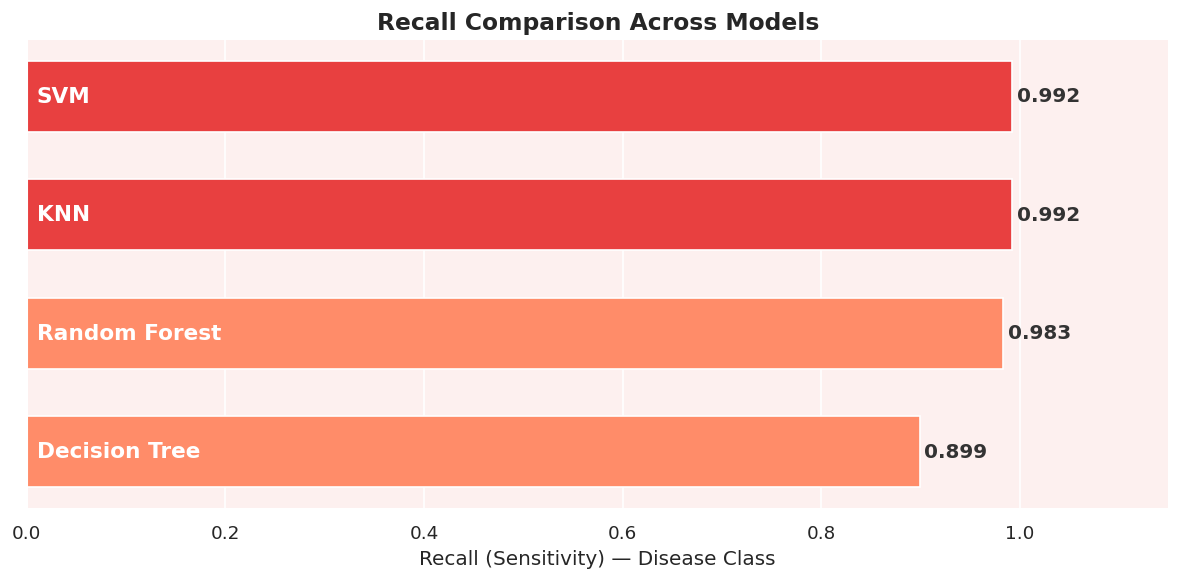

In [77]:
results_sorted_r = results.sort_values('recall_1', ascending=True)
fig, ax = plt.subplots(figsize=(10, 5))
colors_r = [PALETTE[0] if v == results_sorted_r['recall_1'].max() else PALETTE[1]
            for v in results_sorted_r['recall_1']]
bars = ax.barh(results_sorted_r.index, results_sorted_r['recall_1'],
               color=colors_r, edgecolor='white', height=0.6)

for bar, val, name in zip(bars, results_sorted_r['recall_1'], results_sorted_r.index):
    ax.text(val + 0.005, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontweight='bold', fontsize=12, color='#333')
    ax.text(0.01, bar.get_y() + bar.get_height()/2,
            name, va='center', fontsize=13, fontweight='bold', color='white')

ax.set_xlim([0, 1.15])
ax.set_yticks([])
ax.set_xlabel('Recall (Sensitivity) — Disease Class', fontsize=12)
ax.set_title('Recall Comparison Across Models', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


### 9.4 Confusion Matrices — All Models

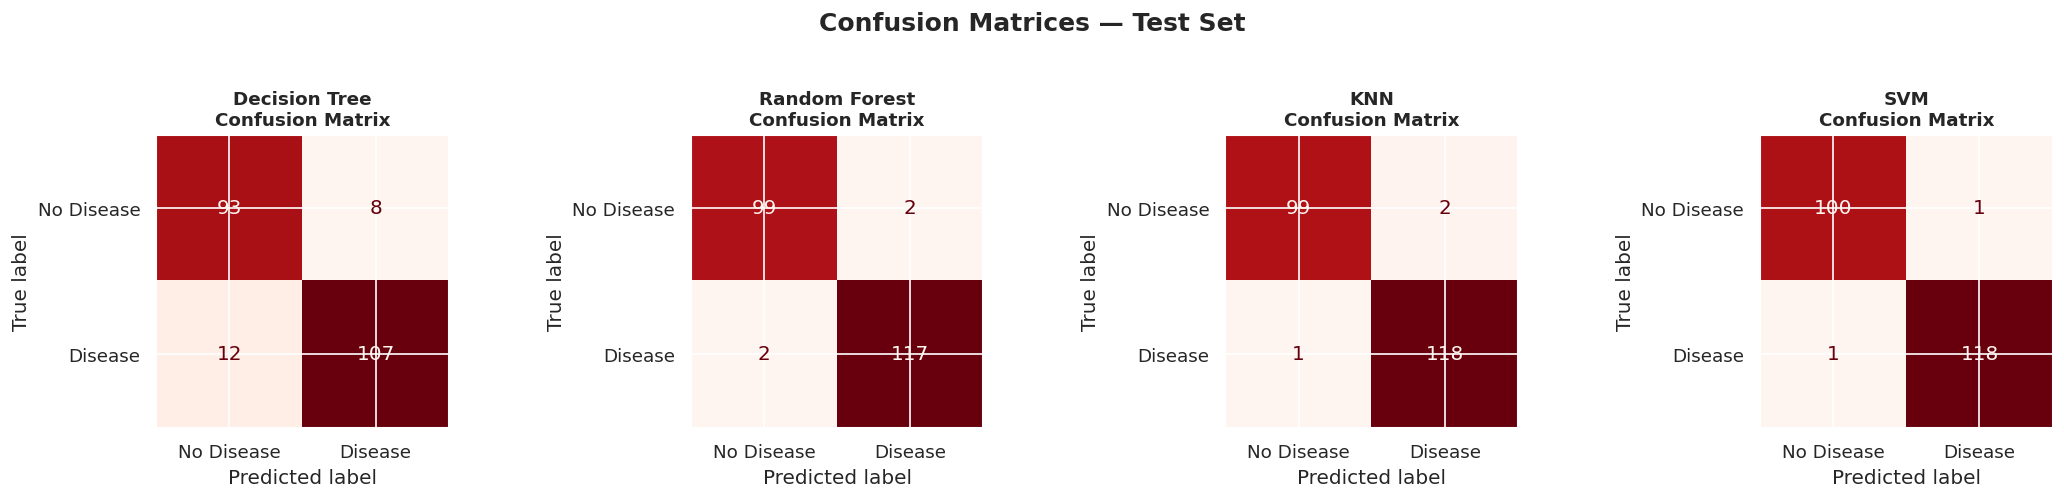

In [78]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
models = [best_dt, best_rf, best_knn, best_svm]
names  = ['Decision Tree', 'Random Forest', 'KNN', 'SVM']

for model, name, ax in zip(models, names, axes):
    plot_confusion_matrix(model, X_test, y_test, name, ax)

plt.suptitle('Confusion Matrices — Test Set', fontsize=15,
             fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()


### 9.5 ROC Curves — All Models

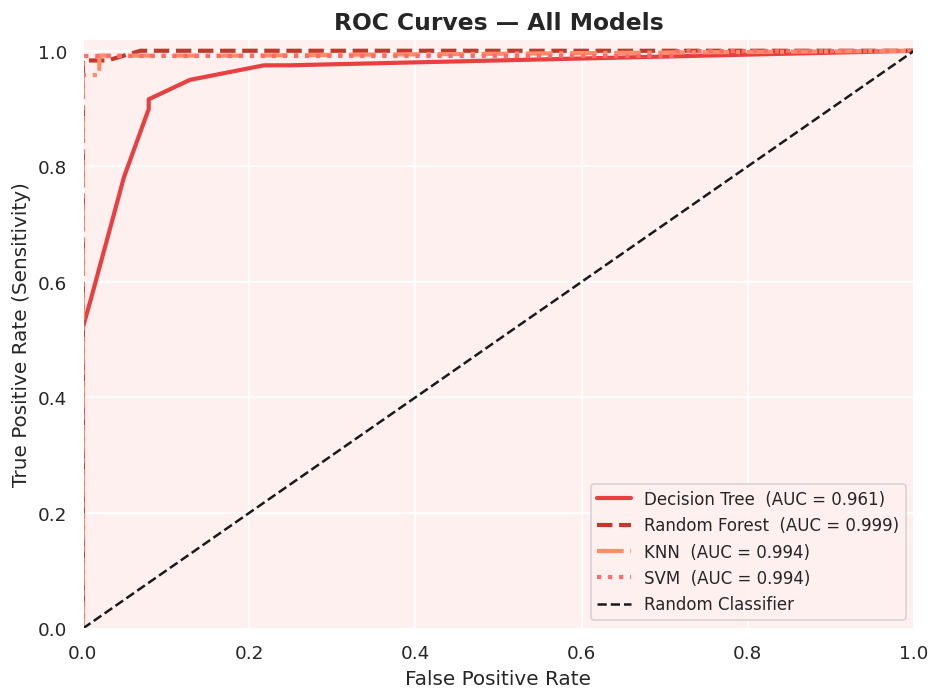

In [79]:
fig, ax = plt.subplots(figsize=(8, 6))
line_styles = ['-', '--', '-.', ':']
colors_roc  = ['#E84040', '#c0392b', '#FF8C69', '#ff6b6b']

for model, name, ls, color in zip(models, names, line_styles, colors_roc):
    y_prob = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, lw=2.5, linestyle=ls, color=color,
            label=f'{name}  (AUC = {roc_auc:.3f})')

ax.plot([0, 1], [0, 1], 'k--', lw=1.5, label='Random Classifier')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate (Sensitivity)', fontsize=12)
ax.set_title('ROC Curves — All Models', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=10)
ax.set_xlim([0, 1]); ax.set_ylim([0, 1.02])
plt.tight_layout()
plt.show()


### 9.6 Multi-Metric Performance Heatmap

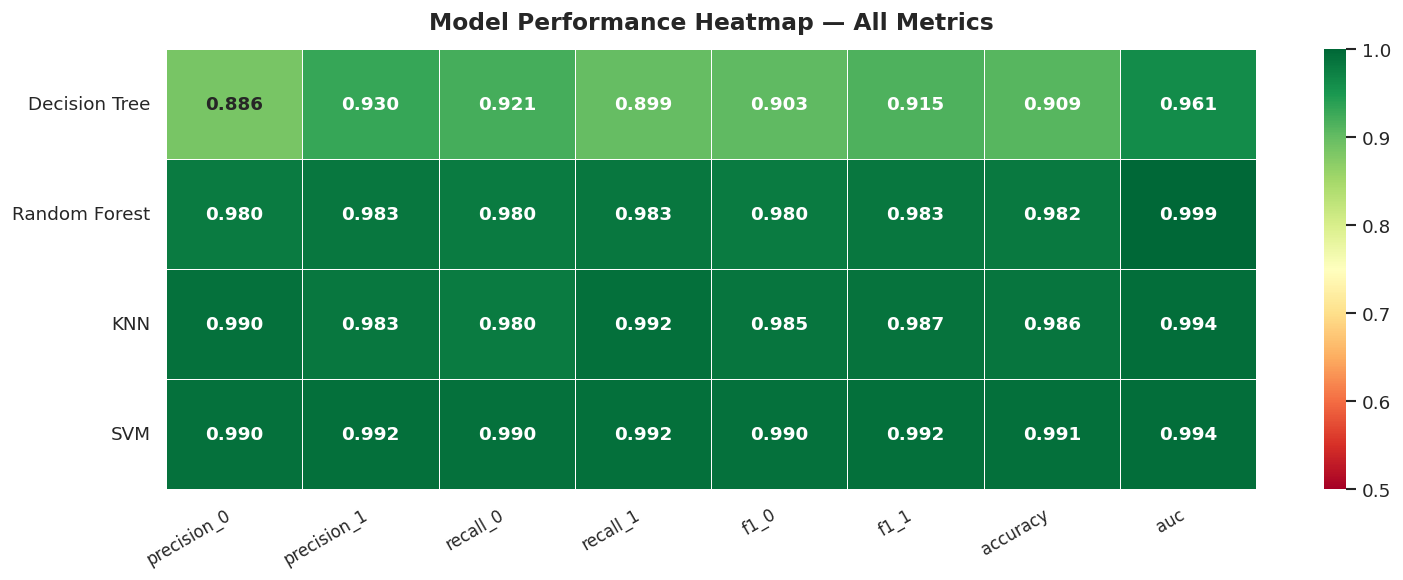

In [80]:
plot_metrics = ['precision_0', 'precision_1', 'recall_0', 'recall_1',
                'f1_0', 'f1_1', 'accuracy', 'auc']

fig, ax = plt.subplots(figsize=(13, 5))
sns.heatmap(results[plot_metrics].astype(float),
            annot=True, fmt='.3f', cmap='RdYlGn',
            vmin=0.5, vmax=1.0,
            linewidths=0.5, linecolor='white',
            annot_kws={'size': 11, 'weight': 'bold'}, ax=ax)
ax.set_title('Model Performance Heatmap — All Metrics',
             fontsize=14, fontweight='bold', pad=12)
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right', fontsize=10)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=11)
plt.tight_layout()
plt.show()


---
## 9.7 Conclusion

### 🏆 Best Model: **Support Vector Machine (SVM)**

SVM achieves the **highest performance across nearly every metric** on the test set:

| Metric                 | Decision Tree | Random Forest |  KNN  |  **SVM**  |
| ---------------------- | :-----------: | :-----------: | :---: | :-------: |
| Precision (Disease)    |     0.930     |     0.983     | 0.983 | **0.992** |
| **Recall (Disease)**   |     0.899     |     0.983     | 0.992 | **0.992** |
| **F1 (Disease)**       |     0.915     |     0.983     | 0.987 | **0.992** |
| Precision (No Disease) |     0.886     |     0.980     | 0.990 | **0.990** |
| Recall (No Disease)    |     0.921     |     0.980     | 0.980 | **0.990** |
| F1 (No Disease)        |     0.903     |     0.980     | 0.985 | **0.990** |
| **Accuracy**           |     0.909     |     0.982     | 0.986 | **0.991** |
| **AUC-ROC**            |     0.961     |   **0.999**   | 0.994 |   0.994   |


**Confusion Matrix (SVM, Test Set):**
- True Negatives (No Disease, correctly identified): **100**
- False Positives (healthy patients misclassified): **1**
- False Negatives (missed disease cases): **1**
- True Positives (Disease, correctly identified): **118**

Only **2 errors** out of 220 test samples.

---

### 🏅 Full Model Rankings

| Rank | Model | Strengths | Limitations |
|------|-------|-----------|-------------|
| 🥇 **1** | **SVM** | Highest F1 (0.992), accuracy (0.991), recall (0.992) across both classes. Only 1 false negative and 1 false positive on the test set. Finds an optimal global margin separator. | Less interpretable; slower to tune; sensitive to kernel/C choice. |
| 🥈 **2** | **KNN** | Near-equal recall (0.992), excellent F1 (0.987). AUC tied with SVM (0.994). Performs consistently. | No explicit model to interpret; computationally expensive at inference for large datasets. |
| 🥉 **3** | **Random Forest** | Highest AUC (0.999), highly consistent metrics. Provides feature importances for clinical interpretability. Robust to overfitting. | Slightly lower recall (0.983) than SVM/KNN for the disease class. |
| **4** | **Decision Tree** | Fully explainable structure; can be audited rule-by-rule. Suitable for regulatory review. | Significantly weaker performance (F1 = 0.915, recall = 0.899). Highest false negative count (12). |

---

### 🏥 Clinical Significance

In a cardiac risk screening context, the priority objective is:
1. **Maximise recall (sensitivity)** for the Disease class — every missed positive is a patient at risk of Sudden Cardiac Arrest who goes undiagnosed.
2. **Maintain high precision** — excessive false positives cause unnecessary anxiety, invasive tests, and healthcare resource strain.

The **SVM achieves the optimal clinical balance**: only **1 false negative** (missed disease case) and only **1 false positive** across the entire test set. This makes it the strongest candidate for deployment in a Clinical Decision Support System for SCA risk prediction.

**Random Forest** is the recommended secondary model in contexts where explainability or regulatory transparency is required, as its feature importance scores provide direct clinical insight into which patient attributes most strongly predict disease.

---

### 🔬 Future Work

- **External validation** — test on an independent, larger multi-centre clinical cohort to assess generalisability.
- **Ensemble stacking** — combine SVM + Random Forest predictions for potential marginal gains.
- **SHAP explainability** — apply SHAP values to SVM (kernel SHAP) and RF to produce per-prediction explanations for clinical review.
- **Decision threshold optimisation** — adjust the SVM classification threshold to fine-tune the sensitivity/specificity trade-off for specific clinical settings.
- **Longitudinal validation** — evaluate whether model performance holds over time as patient demographics shift.
- **Real-time API deployment** — develop a REST API wrapping the trained SVM pipeline for integration into electronic health record systems.
